# 🌿 AirNova: Predicting Air Pollution Levels in Sofia

## 1. Project Overview 
AirNova is a machine learning project aimed at **forecasting PM2.5 air pollution levels in Sofia, Bulgaria**.  
The model predicts hourly PM2.5 concentrations based on **historical air quality data** and **weather variables** such as temperature, humidity, wind speed/direction, pressure, and precipitation.  

**Purpose:**  
- Understand patterns of air pollution in Sofia.  
- Identify weather and environmental conditions that influence PM2.5 levels.  
- Provide actionable insights for residents to make safer outdoor decisions.

## 2. Motivation 
Air pollution is a real and pressing issue in Sofia, the capital of my home country, especially during winter months and periods of heavy traffic.  
Many residents, including my family and friends, are affected by poor air quality, which can lead to respiratory problems, allergies, and general discomfort.  

This project is personally relevant to me because:  
- I care about the health and well-being of my family and friends living in Sofia.  
- Understanding and predicting air pollution levels can help people make safer daily decisions, such as when to go outside or exercise.  
- AirNova allows me to apply my skills in data science and machine learning to address a real-world, local problem.  
- By developing a predictive model, I can contribute actionable insights that may improve the quality of life for residents and raise awareness about environmental conditions in Sofia.  

Ultimately, this project connects my technical interests with a meaningful, local challenge that affects people I care about.


## 3. Methodology Overview

We will follow these steps:

1. **Data Collection**  
   - Air quality data: PM2.5, PM10, CO, NO2, SO2, O3  
   - Weather data: Temperature, humidity, wind speed/direction, pressure, precipitation  

2. **Data Cleaning & Preparation**  
   - Handle missing values  
   - Align timestamps  
   - Ensure correct data types  

3. **Exploratory Data Analysis (EDA)**  
   - Understand pollutant distributions  
   - Analyze temporal trends and seasonal patterns  
   - Identify correlations between variables  

4. **Feature Engineering**  
   - Lag features for PM2.5  
   - Cyclical encoding for hour and month  
   - Wind direction encoding  

5. **Modeling**  
   - Linear Regression  
   - Decision Tree Regressor  
   - Random Forest Regressor  

6. **Evaluation & Insights**  
   - Compare model performance  
   - Identify key predictors  
   - Forecast PM2.5 for short-term periods




## Import Libraries

In [ ]:

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

sns.set(style="whitegrid")


## 🗂️ Data Collection

We will collect **historical air pollution** and **weather data** for Sofia, Bulgaria.  

**Coordinates for Sofia:**  
- Latitude: 42.6977  
- Longitude: 23.3219  

**Timeframe:**  
- Last 2 years (hourly measurements)  
- From `2023-09-22` to `2025-09-22`

**Source:** To collect the data, we use the **Open-Meteo Air Quality API**, which is free and does not require an API key. The API allows us to request hourly air pollution data for a specific location and timeframe. The request URL we use for Sofia is as follows:

https://air-quality-api.open-meteo.com/v1/air-quality?
latitude=42.6977&longitude=23.3219
&hourly=pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
&start_date=2023-09-22&end_date=2025-09-22
&timezone=Europe/Sofia



In [3]:
# Air Quality API
latitude = 42.6977
longitude = 23.3219
start_date = "2023-09-22"
end_date = "2025-09-22"

url_air = (
    f"https://air-quality-api.open-meteo.com/v1/air-quality?"
    f"latitude={latitude}&longitude={longitude}"
    f"&hourly=pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone"
    f"&start_date={start_date}&end_date={end_date}"
    f"&timezone=Europe/Sofia"
)

response_air = requests.get(url_air)
data_air = response_air.json()
hourly_air = data_air.get("hourly", {})
df_air = pd.DataFrame(hourly_air)
df_air["time"] = pd.to_datetime(df_air["time"])
df_air = df_air.set_index("time").dropna()

df_air.to_csv("sofia_air_quality.csv")
print(f"✅ Air quality data collected: {df_air.shape[0]} rows, {df_air.shape[1]} columns")

# Weather API
url_weather = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={latitude}&longitude={longitude}"
    f"&hourly=temperature_2m,relative_humidity_2m,windspeed_10m,winddirection_10m,pressure_msl,precipitation"
    f"&start_date={start_date}&end_date={end_date}"
    f"&timezone=Europe/Sofia"
)

response_weather = requests.get(url_weather)
data_weather = response_weather.json()
hourly_weather = data_weather.get("hourly", {})
df_weather = pd.DataFrame(hourly_weather)
df_weather["time"] = pd.to_datetime(df_weather["time"])
df_weather = df_weather.set_index("time").dropna()

df_weather.to_csv("sofia_weather.csv")
print(f"✅ Weather data collected: {df_weather.shape[0]} rows, {df_weather.shape[1]} columns")


✅ Air quality data collected: 17568 rows, 6 columns
✅ Weather data collected: 17568 rows, 6 columns


##  Data Cleaning & Preparation

Before we start predicting PM2.5 levels, we need to clean, inspect, and merge our air pollution and weather datasets. This ensures our data is consistent and ready for analysis.

**Steps:**  
1. Check and remove missing values.  
2. Merge air quality and weather datasets on `time`.  
3. Save a clean dataset.



### Inspect Raw Datasets

In [4]:
import pandas as pd

df_air = pd.read_csv("sofia_air_quality.csv", parse_dates=["time"])
df_weather = pd.read_csv("sofia_weather.csv", parse_dates=["time"])

print("Air Pollution Data Preview:")
display(df_air.head())

print("Weather Data Preview:")
display(df_weather.head())


Air Pollution Data Preview:


,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
0,2023-09-22 00:00:00,12.8,26.4,227.0,11.1,11.1,60.0
1,2023-09-22 01:00:00,12.4,25.6,221.0,9.4,9.9,61.0
2,2023-09-22 02:00:00,11.3,27.8,233.0,7.6,9.5,60.0
3,2023-09-22 03:00:00,13.2,26.6,224.0,7.1,8.4,58.0
4,2023-09-22 04:00:00,13.2,26.4,249.0,6.7,9.0,54.0


Weather Data Preview:


,time,temperature_2m,relative_humidity_2m,windspeed_10m,winddirection_10m,pressure_msl,precipitation
0,2023-09-22 00:00:00,16.5,87,7.8,68,1015.1,0.0
1,2023-09-22 01:00:00,15.3,92,9.0,90,1015.6,0.0
2,2023-09-22 02:00:00,15.8,88,7.9,51,1015.9,0.0
3,2023-09-22 03:00:00,15.9,88,8.6,2,1016.9,0.0
4,2023-09-22 04:00:00,16.0,85,6.1,152,1016.5,0.0


In [5]:
print(f"Air Pollution Dataset Shape: {df_air.shape}")
print(f"Columns: {df_air.columns.tolist()}")

print(f"Weather Dataset Shape: {df_weather.shape}")
print(f"Columns: {df_weather.columns.tolist()}")


Air Pollution Dataset Shape: (17568, 7)
Columns: ['time', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']
Weather Dataset Shape: (17568, 7)
Columns: ['time', 'temperature_2m', 'relative_humidity_2m', 'windspeed_10m', 'winddirection_10m', 'pressure_msl', 'precipitation']


### Visualize Missing Values




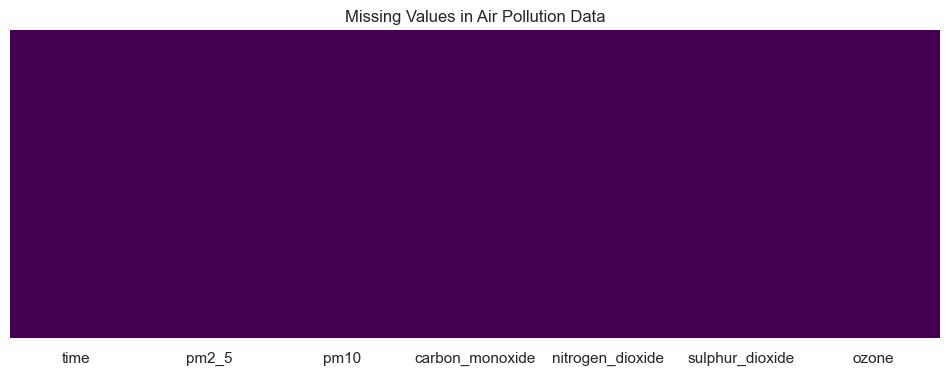

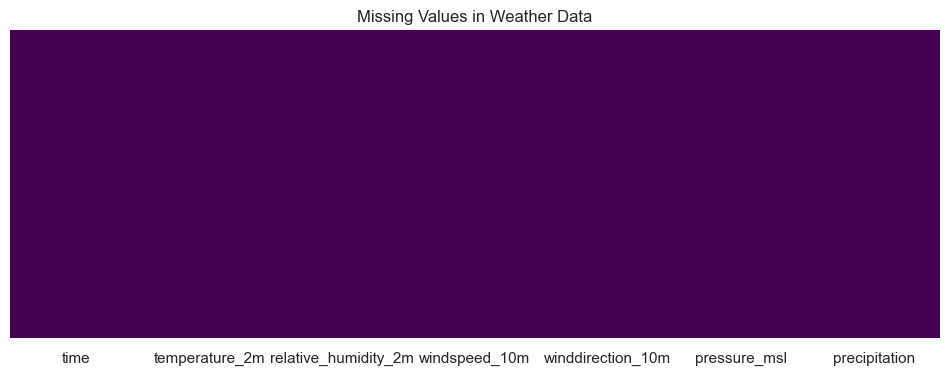

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,4))
sns.heatmap(df_air.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values in Air Pollution Data")
plt.show()

plt.figure(figsize=(12,4))
sns.heatmap(df_weather.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values in Weather Data")
plt.show()

### Merge Air Pollution and Weather Data

In [7]:
# Merge on timestamp
df_merged = pd.merge(df_air, df_weather, left_index=True, right_index=True, how='inner')

print(f"Merged Dataset Shape: {df_merged.shape}")
print("Columns in Merged Dataset:")
display(df_merged.columns.tolist())
df_merged.to_csv("merged_air_weather_data.csv", index=True)
print(" Merged dataset saved as 'merged_air_weather_data.csv'")

Merged Dataset Shape: (17568, 14)
Columns in Merged Dataset:


['time_x',
 'pm2_5',
 'pm10',
 'carbon_monoxide',
 'nitrogen_dioxide',
 'sulphur_dioxide',
 'ozone',
 'time_y',
 'temperature_2m',
 'relative_humidity_2m',
 'windspeed_10m',
 'winddirection_10m',
 'pressure_msl',
 'precipitation']

 Merged dataset saved as 'merged_air_weather_data.csv'


### Inspect Merged Data

In [8]:

print("\nSample Data:")
display(df_merged.head())


print("\nMissing Values per Column:")
print(df_merged.isnull().sum())


Sample Data:


,time_x,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,time_y,temperature_2m,relative_humidity_2m,windspeed_10m,winddirection_10m,pressure_msl,precipitation
0,2023-09-22 00:00:00,12.8,26.4,227.0,11.1,11.1,60.0,2023-09-22 00:00:00,16.5,87,7.8,68,1015.1,0.0
1,2023-09-22 01:00:00,12.4,25.6,221.0,9.4,9.9,61.0,2023-09-22 01:00:00,15.3,92,9.0,90,1015.6,0.0
2,2023-09-22 02:00:00,11.3,27.8,233.0,7.6,9.5,60.0,2023-09-22 02:00:00,15.8,88,7.9,51,1015.9,0.0
3,2023-09-22 03:00:00,13.2,26.6,224.0,7.1,8.4,58.0,2023-09-22 03:00:00,15.9,88,8.6,2,1016.9,0.0
4,2023-09-22 04:00:00,13.2,26.4,249.0,6.7,9.0,54.0,2023-09-22 04:00:00,16.0,85,6.1,152,1016.5,0.0



Missing Values per Column:
time_x                  0
pm2_5                   0
pm10                    0
carbon_monoxide         0
nitrogen_dioxide        0
sulphur_dioxide         0
ozone                   0
time_y                  0
temperature_2m          0
relative_humidity_2m    0
windspeed_10m           0
winddirection_10m       0
pressure_msl            0
precipitation           0
dtype: int64


#### Merged Dataset Overview

We merged the **air quality dataset** with the **weather dataset** based on the `time` column. After merging, the dataset contains the following columns:

- **Air Quality Variables:**
  - `pm2_5` – Fine particulate matter (µg/m³)
  - `pm10` – Coarse particulate matter (µg/m³)
  - `carbon_monoxide` – CO concentration (µg/m³)
  - `nitrogen_dioxide` – NO₂ concentration (µg/m³)
  - `sulphur_dioxide` – SO₂ concentration (µg/m³)
  - `ozone` – O₃ concentration (µg/m³)
- **Weather Variables:**
  - `temperature_2m` – Temperature at 2 meters (°C)
  - `relative_humidity_2m` – Relative humidity (%)
  - `windspeed_10m` – Wind speed at 10 meters (m/s)
  - `winddirection_10m` – Wind direction at 10 meters (°)
  - `pressure_msl` – Atmospheric pressure (hPa)
  - `precipitation` – Precipitation (mm)
- **Time Columns:** `time_x` and `time_y` (from air quality and weather datasets respectively)

### Observations:

- The merged dataset contains **17,568 rows** (hourly measurements over 2 years) and **14 numeric columns**.
- **Air quality measurements**:
  - `pm2_5` ranges from 1.8 to 136.3 µg/m³ 
  - `pm10` ranges from 2.1 to 142.6 µg/m³
  - `carbon_monoxide` ranges from 112 to 968 µg/m³ 
  - Other pollutants show typical urban air variability.
- **Weather measurements**:
  - `temperature_2m` ranges from -14°C to 37.8°C
  - `relative_humidity_2m` ranges from 13% to 100%
  - `windspeed_10m` ranges from 0 to 33.5 m/s
  - `pressure_msl` ranges from 991.1 hPa to 1043.3 hPa
  - `precipitation` ranges from 0 to 14.9 mm


# Evaluation 0 — Data Collection Phase

Before proceeding with modeling, I evaluated the quality and structure of the raw data collected from the **Open-Meteo Air Quality** and **Weather APIs**.  
The datasets provided hourly granularity over a two-year window (2023–2025) and covered key atmospheric and pollutant variables.

**Findings:**
- The data was **consistent and complete**, with no major gaps in timestamps.  
- Weather variables such as temperature, humidity, and windspeed exhibited **expected seasonal behavior**, confirming data reliability.


# Exploratory Data Analysis (EDA) Objectives

The purpose of the Exploratory Data Analysis (EDA) is to **understand the underlying structure, patterns, and relationships within the dataset** before any predictive modeling. In this project, we will perform EDA on combined air quality and weather data for Sofia, covering hourly measurements from September 2023 to September 2025.  

The key steps in our EDA will include:

1. **Visualizing Distributions and Correlations:**  
   To gain a deeper understanding, we will create **visualizations** like histograms, boxplots, and density plots to examine the distributions of each variable. Additionally, we will explore the **correlations between air pollutants and weather variables** using heatmaps and scatter plots. This will reveal potential relationships, such as whether higher temperatures or wind speeds influence pollutant levels.

2. **Investigating Temporal Patterns:**  
   Air quality often exhibits **daily, weekly, and seasonal trends** due to human activity and meteorological conditions. We will analyze how pollutant levels vary across different hours of the day, days of the week, and seasons. This will help us detect patterns like higher pollution during morning rush hours or increased levels during winter months.

3. **Identifying Outliers and Extreme Events:**  
   It is important to detect **outliers or extreme pollution events** that could significantly impact overall air quality. These anomalies may indicate unusual conditions, measurement errors, or events such as industrial accidents or weather phenomena. We will use boxplots, z-scores, and time series visualizations to detect such occurrences.

By systematically performing these steps, we aim to **gain a comprehensive understanding of Sofia's air quality and weather dynamics**, identify important trends and patterns, and prepare the dataset for further analysis or predictive modeling.


### Visualizing Distributions

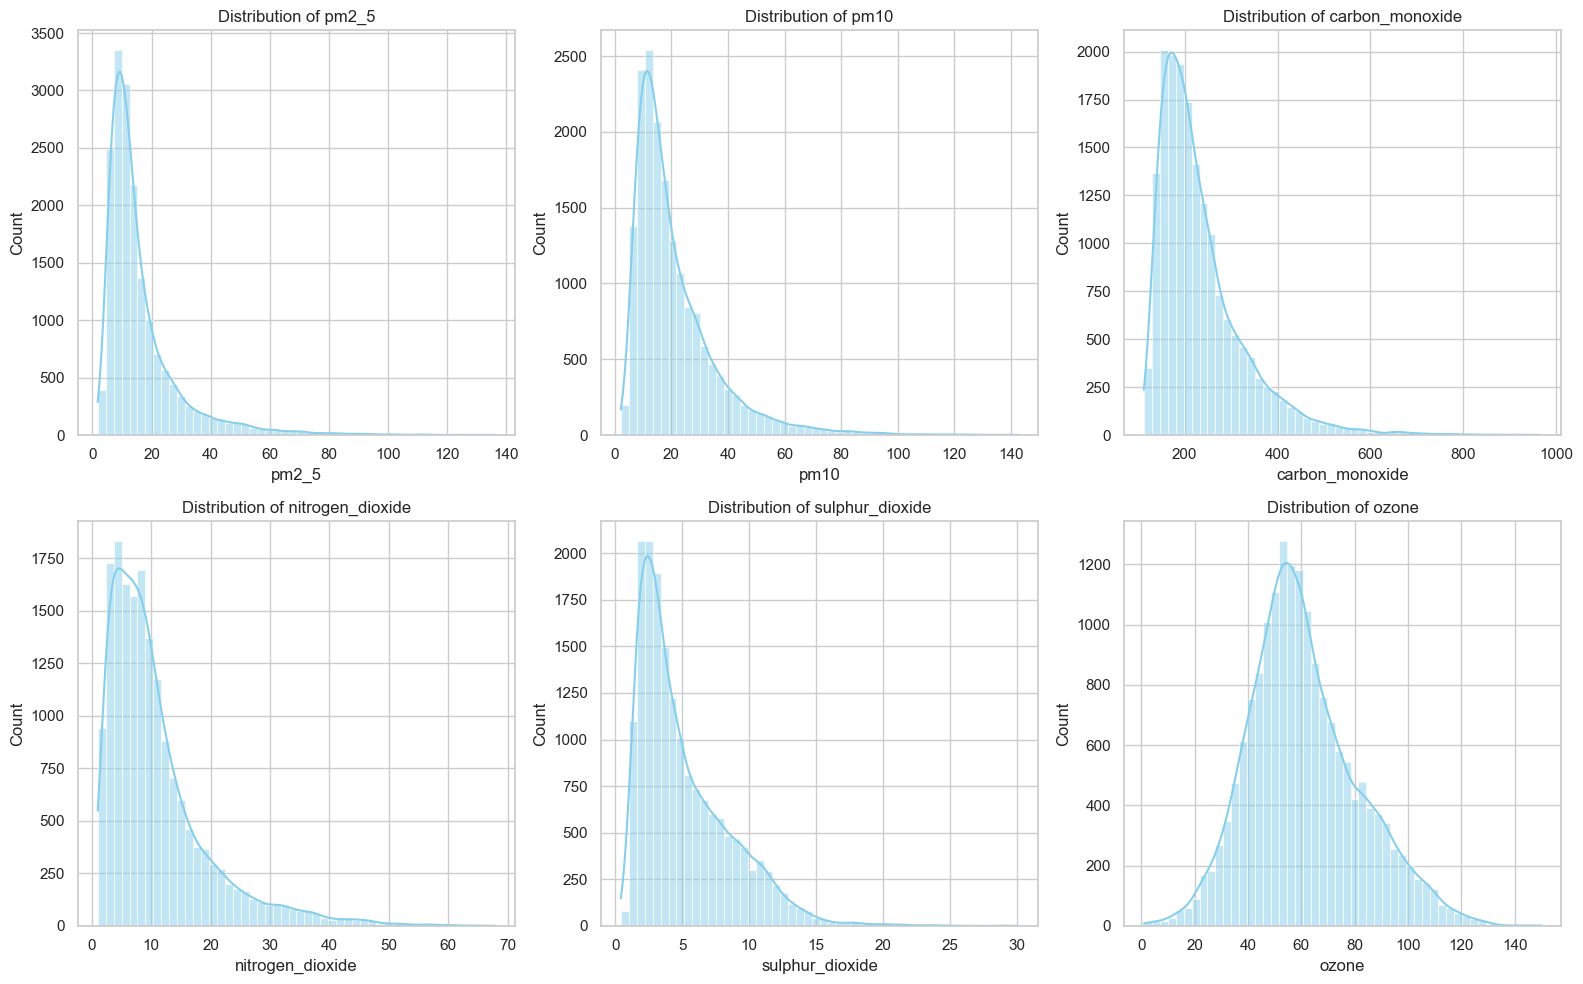

In [9]:
# Distribution plots for pollutants
pollutants = ["pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide", "sulphur_dioxide", "ozone"]

plt.figure(figsize=(16,10))
for i, col in enumerate(pollutants, 1):
    plt.subplot(2,3,i)
    sns.histplot(df_merged[col], bins=50, kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


In these plots, the x-axis represents the concentration of each pollutant, while the y-axis shows the count (frequency) of observations. Most pollutants stay at low levels most of the time, but sometimes there are sudden high readings. This means pollution usually isn’t severe but can spike occasionally. Ozone levels are more steady and balanced compared to the others.

### Correlation Analysis

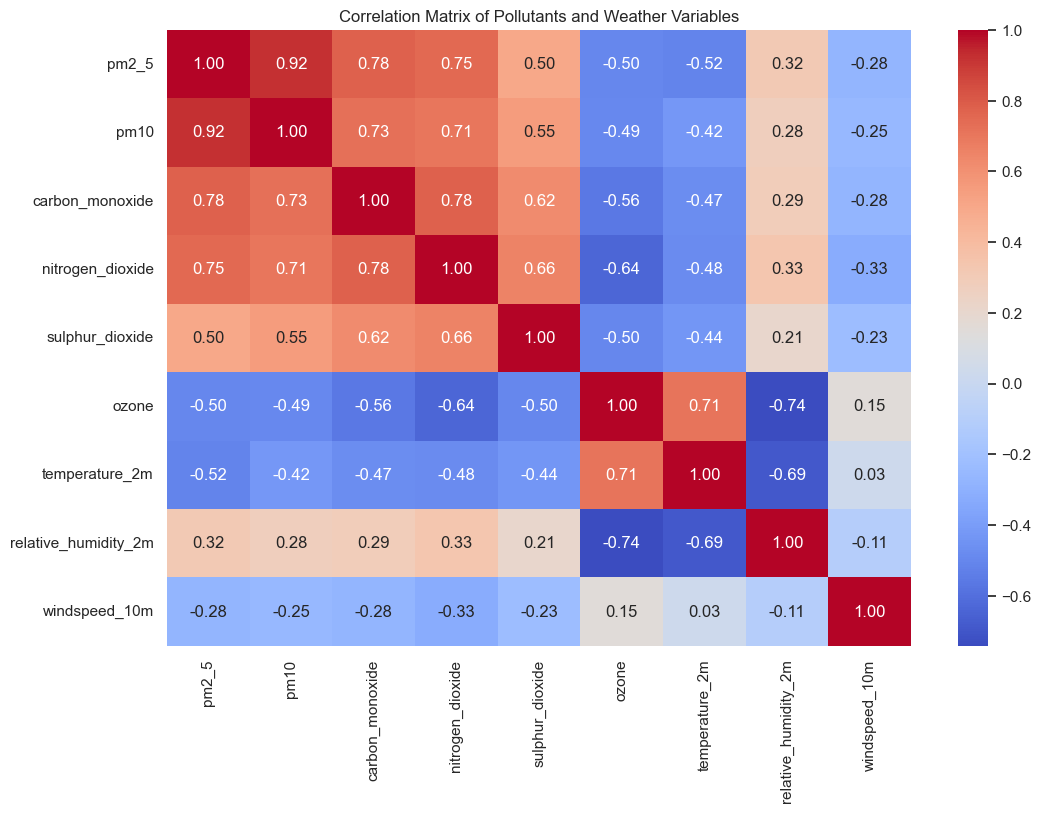

In [10]:

corr = df_merged[pollutants + ["temperature_2m","relative_humidity_2m","windspeed_10m"]].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Pollutants and Weather Variables")
plt.show()


This correlation heatmap shows how air pollutants and weather variables are related to one another. Each cell represents a correlation coefficient (ranging from -1 to +1):

+1 → perfect positive relationship (as one increases, the other also increases)

-1 → perfect negative relationship (as one increases, the other decreases)

0 → no linear relationship

🔴 **Strong Positive Correlations**

- PM2.5, PM10, CO, and NO₂ are strongly correlated (r = 0.7–0.9).
→ These pollutants tend to rise and fall together

- SO₂ is moderately correlated with the above pollutants, showing similar but weaker patterns.

🔵 **Negative Correlations**

- Ozone (O₃) has a negative correlation with most other pollutants (r ≈ -0.5 to -0.6).
→ This means that when primary pollutants like PM or NO₂ are high, ozone tends to be low. This often happens because ozone forms through photochemical reactions that require sunlight, which are less active when pollution is heavy or air is stagnant.

- Temperature also shows a negative correlation with particulate pollutants (r ≈ -0.4 to -0.5), implying that higher temperatures often coincide with cleaner air, possibly due to better dispersion and photochemical activity.

- Relative humidity has a mild positive correlation with particulates (r ≈ 0.3), meaning higher humidity might trap pollutants closer to the ground.

- Wind speed is slightly negatively correlated with pollutants (r ≈ -0.2 to -0.3), suggesting stronger winds help disperse pollutants and improve air quality.

🟡 **Positive Correlation Between Ozone and Temperature**

A strong positive correlation (r ≈ 0.71) exists between ozone and temperature


**Overall Insights**

- Weather conditions (temperature, humidity, wind) play a significant role in pollutant behavior.

- Ozone behaves differently from other pollutants, being more influenced by sunlight and temperature rather than direct emissions.

### Temporal Patterns

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sofia_air_weather_features.csv", parse_dates=["time_x"])
df = df.rename(columns={"time_x": "time"})


df_pm = df[['time', 'pm2_5']].copy()

df_pm['hour'] = df_pm['time'].dt.hour
df_pm['weekday'] = df_pm['time'].dt.day_name()  # Monday, Tuesday, ...
df_pm['month'] = df_pm['time'].dt.month
df_pm['season'] = df_pm['time'].dt.month%12 // 3 + 1  # 1:Winter, 2:Spring, 3:Summer, 4:Autumn
season_dict = {1:'Winter', 2:'Spring', 3:'Summer', 4:'Autumn'}
df_pm['season'] = df_pm['season'].map(season_dict)


#### Hourly Trends

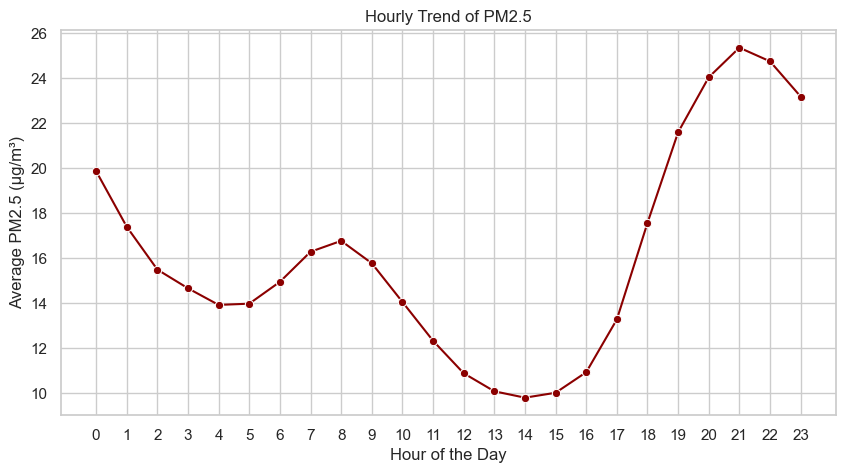

In [ ]:
hourly_pm = df_pm.groupby('hour')['pm2_5'].mean().reset_index()


plt.figure(figsize=(10,5))
sns.lineplot(x='hour', y='pm2_5', data=hourly_pm, marker='o', color='darkred')
plt.title('Hourly Trend of PM2.5')
plt.xlabel('Hour of the Day')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.xticks(range(0,24))
plt.grid(True)
plt.show()


The hourly trend of PM2.5 shows clear daily variation. Levels are highest during late evening and early morning, likely due to traffic and lower wind dispersion at night. Concentrations drop around midday, when sunlight and stronger air movement help disperse pollutants. This pattern suggests that human activity and weather conditions strongly influence PM2.5 levels in Sofia.

#### Weekly Trends

C:\Users\svdy0\AppData\Local\Temp\ipykernel_30524\3919667189.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weekday', y='pm2_5', data=df_pm, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], palette='coolwarm')


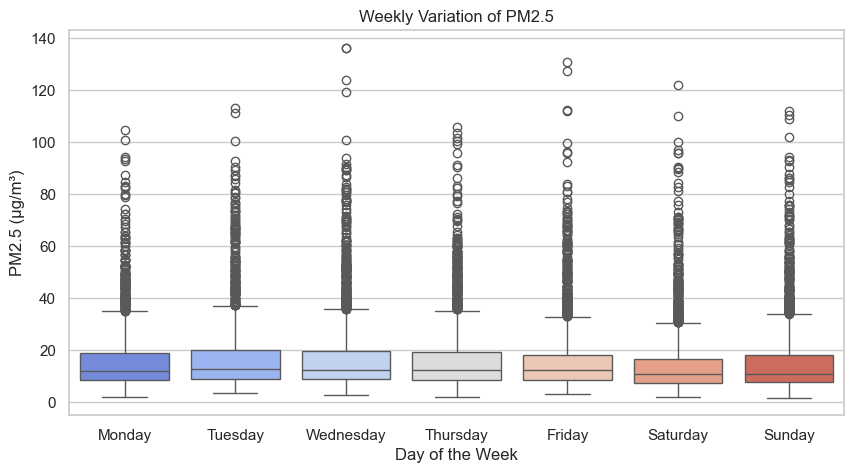

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(x='weekday', y='pm2_5', data=df_pm, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], palette='coolwarm')
plt.title('Weekly Variation of PM2.5')
plt.ylabel('PM2.5 (µg/m³)')
plt.xlabel('Day of the Week')
plt.show()


The weekly variation of PM2.5 shows similar levels across all days, with only small differences. Slightly higher concentrations appear on weekdays, especially at the start of the week, likely due to work and traffic activity. Levels tend to be a bit lower on weekends, suggesting reduced human activity helps improve air quality.

C:\Users\svdy0\AppData\Local\Temp\ipykernel_30524\3604319151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='pm2_5', data=df_pm, palette='YlOrRd')


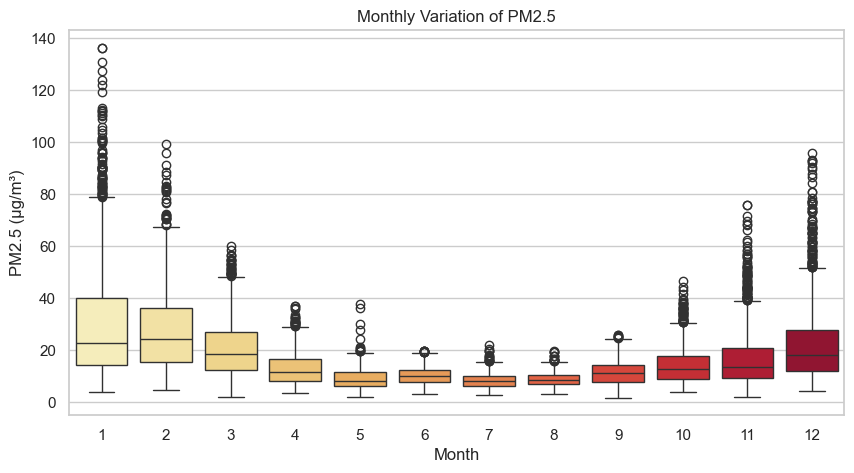

In [14]:
plt.figure(figsize=(10,5))
sns.boxplot(x='month', y='pm2_5', data=df_pm, palette='YlOrRd')
plt.title('Monthly Variation of PM2.5')
plt.ylabel('PM2.5 (µg/m³)')
plt.xlabel('Month')
plt.show()


The monthly variation of PM2.5 shows clear seasonal differences. Levels are highest in winter months (December to February), likely due to heating activities and stagnant cold air. Spring and summer months (April to August) show much lower concentrations, as warmer temperatures and stronger winds help disperse pollutants. The increase in autumn indicates the start of colder weather and more emissions. Overall, PM2.5 levels in Sofia are significantly higher in colder seasons.

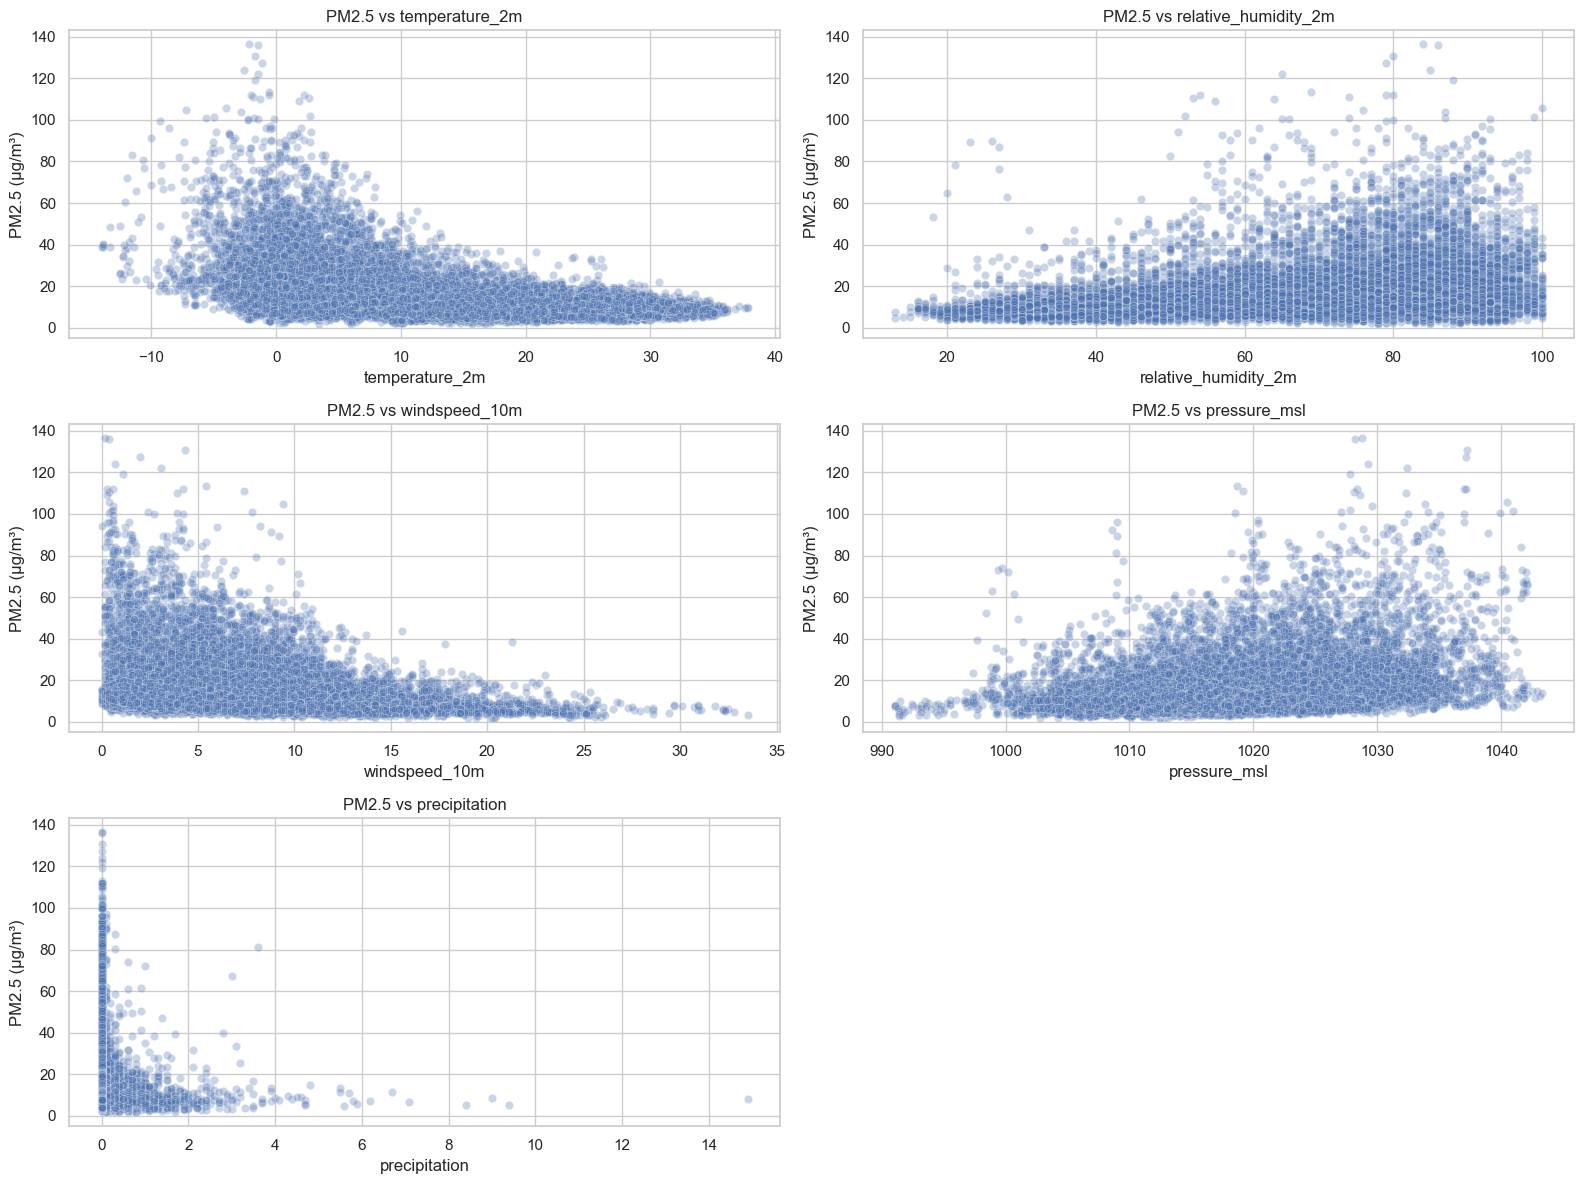

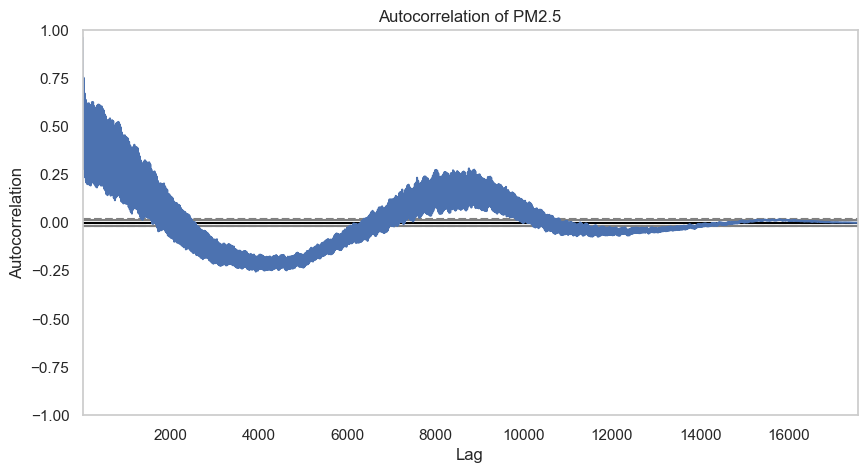

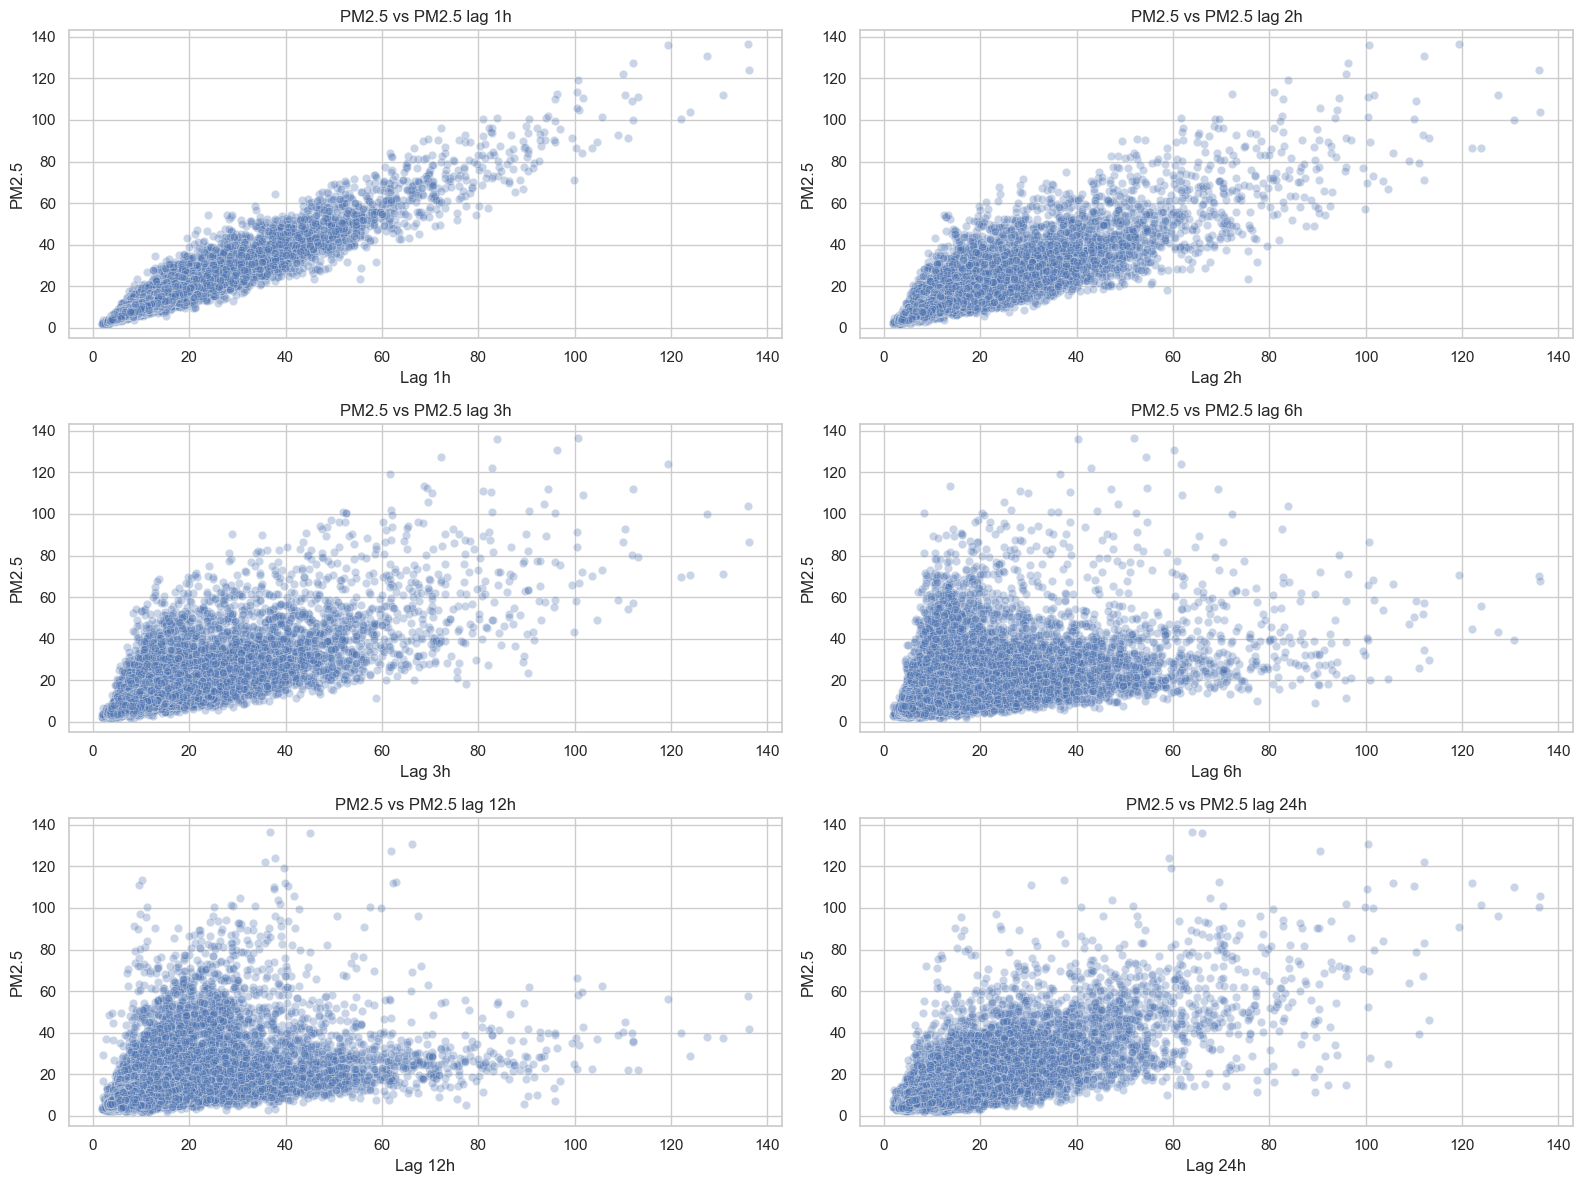

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import autocorrelation_plot

# Load merged dataset
df = pd.read_csv("merged_air_weather_data.csv", parse_dates=["time_x"])
df = df.rename(columns={"time_x": "time"})


weather_vars = ["temperature_2m", "relative_humidity_2m", "windspeed_10m", "pressure_msl", "precipitation"]
target = "pm2_5"

# Scatter plots: PM2.5 vs Weather variables
plt.figure(figsize=(16, 12))
for i, col in enumerate(weather_vars, 1):
    plt.subplot(3, 2, i)
    sns.scatterplot(x=df[col], y=df[target], alpha=0.3)
    plt.title(f'PM2.5 vs {col}')
    plt.xlabel(col)
    plt.ylabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.show()

# Autocorrelation plot for PM2.5
plt.figure(figsize=(10, 5))
autocorrelation_plot(df[target])
plt.title("Autocorrelation of PM2.5")
plt.show()


lags = [1, 2, 3, 6, 12, 24]
plt.figure(figsize=(16, 12))
for i, lag in enumerate(lags, 1):
    df[f'pm2_5_lag_{lag}h'] = df[target].shift(lag)
    plt.subplot(3, 2, i)
    sns.scatterplot(x=df[f'pm2_5_lag_{lag}h'], y=df[target], alpha=0.3)
    plt.title(f'PM2.5 vs PM2.5 lag {lag}h')
    plt.xlabel(f'Lag {lag}h')
    plt.ylabel('PM2.5')
plt.tight_layout()
plt.show()


#### Scatter plots

The scatter plots above illustrate the relationship between PM2.5 concentrations and various meteorological variables. Several interesting non-linear patterns can be observed:

**Temperature:** PM2.5 concentrations are generally higher at lower temperatures and tend to decrease as temperature rises. This may be due to thermal inversion effects that trap pollutants near the surface during colder conditions.

**Relative Humidity**: There is a noticeable increase in PM2.5 levels at higher humidity values, indicating that humid air can facilitate particle accumulation and reduce dispersion efficiency.

**Wind Speed:** A clear negative correlation is evident—PM2.5 levels are significantly higher when wind speeds are low, suggesting that air stagnation leads to pollutant buildup.

**Pressure:** Higher pressure conditions appear to be associated with slightly elevated PM2.5 values, likely because stable high-pressure systems reduce vertical air mixing.

**Precipitation:** PM2.5 decreases sharply with increasing rainfall, confirming that precipitation helps wash out airborne particulates from the atmosphere.

Overall, these relationships suggest that PM2.5 is heavily influenced by meteorological conditions, with wind speed, humidity, and temperature playing the most significant roles. These insights support including weather-related and lagged variables in the predictive modeling phase.

#### Autocorrelation of PM2.5

The autocorrelation plot of PM2.5 reveals clear temporal dependencies in air pollution levels. The pattern shows that:

Strong positive autocorrelation exists at short lags, indicating that recent PM2.5 values are highly predictive of near-future values.

The correlation gradually decreases and becomes negative at mid-range lags, suggesting cyclic or oscillatory behavior in PM2.5 levels.

Subsequent positive peaks at longer lags indicate potential daily or multi-day cycles, likely reflecting consistent human activities and weather patterns.

Overall, this pattern confirms that PM2.5 values are not independent over time and justifies the inclusion of lag-based and rolling statistical features (e.g., past PM2.5 values, moving averages) in the modeling phase to capture temporal dynamics effectively.

#### Lag Feature Analysis (PM2.5 Temporal Dependence)

The scatter plots above show the relationship between current PM2.5 concentrations and their lagged values at different time intervals (1h, 2h, 3h, 6h, 12h, and 24h).

**Observations:**

There is a strong linear correlation between PM2.5 and its short-term lags (1–3 hours), indicating that recent PM2.5 values are highly predictive of the current level.

As the lag increases (6–24 hours), the relationship gradually weakens and becomes more dispersed, suggesting that temporal influence decreases over time.

The visible correlation at 24 hours indicates daily cyclical behavior, consistent with the patterns observed in the autocorrelation plot.

**Conclusion:**
These findings reinforce the importance of including lag-based features (e.g., previous hour PM2.5 readings) in the predictive model to capture temporal continuity and short-term dependencies in air pollution dynamics.

# Feature Engineering for PM2.5 Prediction

In this chapter, we create new features that help our model capture patterns in PM2.5 pollution levels. Feature engineering is essential for time-series problems like air quality prediction because pollutants depend on **temporal trends, meteorological conditions, and previous pollution levels**.

Our main focus is the **PM2.5** pollutant, which is the target variable for modeling.


In [16]:
import pandas as pd

df = pd.read_csv("merged_air_weather_data.csv", parse_dates=["time_x"])
df = df.rename(columns={"time_x": "time"})

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (17568, 15)


,Unnamed: 0,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,time_y,temperature_2m,relative_humidity_2m,windspeed_10m,winddirection_10m,pressure_msl,precipitation
0,0,2023-09-22 00:00:00,12.8,26.4,227.0,11.1,11.1,60.0,2023-09-22 00:00:00,16.5,87,7.8,68,1015.1,0.0
1,1,2023-09-22 01:00:00,12.4,25.6,221.0,9.4,9.9,61.0,2023-09-22 01:00:00,15.3,92,9.0,90,1015.6,0.0
2,2,2023-09-22 02:00:00,11.3,27.8,233.0,7.6,9.5,60.0,2023-09-22 02:00:00,15.8,88,7.9,51,1015.9,0.0
3,3,2023-09-22 03:00:00,13.2,26.6,224.0,7.1,8.4,58.0,2023-09-22 03:00:00,15.9,88,8.6,2,1016.9,0.0
4,4,2023-09-22 04:00:00,13.2,26.4,249.0,6.7,9.0,54.0,2023-09-22 04:00:00,16.0,85,6.1,152,1016.5,0.0


## Creating Lag Features

PM2.5 levels are highly influenced by their recent values.
We create lag features for several past hours to capture short-term temporal dependence.

In [17]:

lags = [1, 2, 3, 6, 12, 24]
for lag in lags:
    df[f'pm2_5_lag_{lag}h'] = df['pm2_5'].shift(lag)


## Rolling Window Features

Rolling windows smooth fluctuations, capture trends, and make features more informative for prediction.

In [ ]:

df['pm2_5_roll_mean_3h'] = df['pm2_5'].rolling(window=3).mean()
df['pm2_5_roll_std_3h']  = df['pm2_5'].rolling(window=3).std()

df['pm2_5_roll_mean_6h'] = df['pm2_5'].rolling(window=6).mean()
df['pm2_5_roll_std_6h']  = df['pm2_5'].rolling(window=6).std()


## Cyclical Time Encoding

Since time is cyclical (e.g., hour 23 and 0 are close), we use sine and cosine transformations to encode time-based patterns without losing continuity. Cyclical encoding allows the model to learn daily, weekly, and seasonal cycles smoothly.


In [ ]:
df['hour'] = df['time'].dt.hour
df['dayofweek'] = df['time'].dt.dayofweek
df['month'] = df['time'].dt.month

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df = df.drop(columns=['hour', 'dayofweek', 'month'])

#### Weather Interaction Features

We create features combining weather variables that may jointly affect air quality (e.g., humidity and temperature). These features capture non-linear meteorological effects on PM2.5 formation and dispersion.

In [20]:

df['temp_humidity'] = df['temperature_2m'] * df['relative_humidity_2m']
df['wind_temp'] = df['windspeed_10m'] * df['temperature_2m']


In [21]:

df['pm2_5_future_3h'] = df['pm2_5'].shift(-3)


In [22]:
print("Missing values BEFORE imputation:")
missing_before = df.isnull().sum()
display(missing_before[missing_before > 0].sort_values(ascending=False))


Missing values BEFORE imputation:


pm2_5_lag_24h         24
pm2_5_lag_12h         12
pm2_5_lag_6h           6
pm2_5_roll_std_6h      5
pm2_5_roll_mean_6h     5
pm2_5_lag_3h           3
pm2_5_future_3h        3
pm2_5_roll_mean_3h     2
pm2_5_lag_2h           2
pm2_5_roll_std_3h      2
pm2_5_lag_1h           1
dtype: int64

In [23]:

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].interpolate(method='linear', limit_direction='both')


df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())


In [24]:
print("✅ Missing Values AFTER Imputation:")
missing_after = df.isnull().sum()
display(missing_after[missing_after > 0])


✅ Missing Values AFTER Imputation:


Series([], dtype: int64)

In [25]:
print("Final Dataset Shape:", df.shape)
df.head(20)  


Final Dataset Shape: (17568, 34)


,Unnamed: 0,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,time_y,temperature_2m,...,pm2_5_roll_std_6h,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,month_sin,month_cos,temp_humidity,wind_temp,pm2_5_future_3h
0,0,2023-09-22 00:00:00,12.8,26.4,227.0,11.1,11.1,60.0,2023-09-22 00:00:00,16.5,...,0.717403,0.000000e+00,1.000000e+00,-0.433884,-0.900969,-1.0,-1.836970e-16,1435.5,128.70,13.2
1,1,2023-09-22 01:00:00,12.4,25.6,221.0,9.4,9.9,61.0,2023-09-22 01:00:00,15.3,...,0.717403,2.588190e-01,9.659258e-01,-0.433884,-0.900969,-1.0,-1.836970e-16,1407.6,137.70,13.2
2,2,2023-09-22 02:00:00,11.3,27.8,233.0,7.6,9.5,60.0,2023-09-22 02:00:00,15.8,...,0.717403,5.000000e-01,8.660254e-01,-0.433884,-0.900969,-1.0,-1.836970e-16,1390.4,124.82,12.9
3,3,2023-09-22 03:00:00,13.2,26.6,224.0,7.1,8.4,58.0,2023-09-22 03:00:00,15.9,...,0.717403,7.071068e-01,7.071068e-01,-0.433884,-0.900969,-1.0,-1.836970e-16,1399.2,136.74,13.2
4,4,2023-09-22 04:00:00,13.2,26.4,249.0,6.7,9.0,54.0,2023-09-22 04:00:00,16.0,...,0.717403,8.660254e-01,5.000000e-01,-0.433884,-0.900969,-1.0,-1.836970e-16,1360.0,97.60,13.3
5,5,2023-09-22 05:00:00,12.9,27.8,296.0,7.7,8.6,52.0,2023-09-22 05:00:00,14.5,...,0.717403,9.659258e-01,2.588190e-01,-0.433884,-0.900969,-1.0,-1.836970e-16,1319.5,94.25,13.9
6,6,2023-09-22 06:00:00,13.2,30.3,339.0,11.2,10.5,44.0,2023-09-22 06:00:00,14.3,...,0.753658,1.000000e+00,6.123234e-17,-0.433884,-0.900969,-1.0,-1.836970e-16,1301.3,112.97,13.6
7,7,2023-09-22 07:00:00,13.3,31.9,387.0,15.2,8.9,43.0,2023-09-22 07:00:00,15.4,...,0.771362,9.659258e-01,-2.588190e-01,-0.433884,-0.900969,-1.0,-1.836970e-16,1355.2,97.02,13.4
8,8,2023-09-22 08:00:00,13.9,31.8,393.0,15.6,10.7,37.0,2023-09-22 08:00:00,17.6,...,0.331160,8.660254e-01,-5.000000e-01,-0.433884,-0.900969,-1.0,-1.836970e-16,1390.4,147.84,13.8
9,9,2023-09-22 09:00:00,13.6,29.2,330.0,12.4,9.2,44.0,2023-09-22 09:00:00,19.9,...,0.350714,7.071068e-01,-7.071068e-01,-0.433884,-0.900969,-1.0,-1.836970e-16,1373.1,193.03,12.4


In [26]:
df.to_csv("feature_engineered_pm25.csv", index=False)


In [ ]:
df['hour'] = df['time'].dt.hour
df['dayofweek'] = df['time'].dt.dayofweek
df['month'] = df['time'].dt.month
 
print("\n✅ Added new time-based columns:")
print(["hour", "dayofweek", "month", "hour_sin", "hour_cos", "dayofweek_sin", "dayofweek_cos", "month_sin", "month_cos"])


display(df.tail())

df.to_csv("feature_engineered_pm25_with_raw_time.csv", index=False)
print("\n Saved updated dataset as 'feature_engineered_pm25_with_raw_time.csv'")


✅ Added new time-based columns:
['hour', 'dayofweek', 'month', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos']


,Unnamed: 0,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,time_y,temperature_2m,...,dayofweek_sin,dayofweek_cos,month_sin,month_cos,temp_humidity,wind_temp,pm2_5_future_3h,hour,dayofweek,month
17563,17563,2025-09-22 19:00:00,7.6,10.2,201.0,8.1,2.1,66.0,2025-09-22 19:00:00,22.3,...,0.0,1.0,-1.0,-1.836970e-16,557.5,272.06,7.7,19,0,9
17564,17564,2025-09-22 20:00:00,8.2,10.7,186.0,6.5,2.2,64.0,2025-09-22 20:00:00,20.9,...,0.0,1.0,-1.0,-1.836970e-16,564.3,225.72,7.7,20,0,9
17565,17565,2025-09-22 21:00:00,8.0,10.9,207.0,6.9,2.6,69.0,2025-09-22 21:00:00,19.5,...,0.0,1.0,-1.0,-1.836970e-16,624.0,191.10,7.7,21,0,9
17566,17566,2025-09-22 22:00:00,7.7,10.3,208.0,6.4,2.8,63.0,2025-09-22 22:00:00,18.2,...,0.0,1.0,-1.0,-1.836970e-16,691.6,131.04,7.7,22,0,9
17567,17567,2025-09-22 23:00:00,7.7,10.2,205.0,6.2,2.5,60.0,2025-09-22 23:00:00,16.7,...,0.0,1.0,-1.0,-1.836970e-16,751.5,100.20,7.7,23,0,9



 Saved updated dataset as 'feature_engineered_pm25_with_raw_time.csv'


In [28]:
HORIZON_HOURS = 3  
df[f"pm2_5_future_{HORIZON_HOURS}h"] = df["pm2_5"].shift(-HORIZON_HOURS)
df = df.dropna(subset=[f"pm2_5_future_{HORIZON_HOURS}h"])
df.to_csv("feature_engineered_pm25_3h_ahead.csv", index=False)
print("✅ Added future target column and saved new dataset.")


✅ Added future target column and saved new dataset.


# Feature Selection
After completing feature engineering, the next step is to identify which features contribute the most to predicting PM2.5 concentrations.
Selecting the most relevant features helps improve model accuracy, interpretability, and efficiency while reducing overfitting.

We will use 

1. **Correlation Analysis** – check linear relationships with PM2.5  
2. **Recursive Feature Elimination (RFE)** – systematically remove less important features  



## Current PM2.5

In [29]:
import pandas as pd

df_now = pd.read_csv("feature_engineered_pm25.csv", parse_dates=["time"])
print("✅ Current PM2.5 Dataset Loaded:", df_now.shape)
display(df_now.head())


✅ Current PM2.5 Dataset Loaded: (17568, 34)


,Unnamed: 0,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,time_y,temperature_2m,...,pm2_5_roll_std_6h,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,month_sin,month_cos,temp_humidity,wind_temp,pm2_5_future_3h
0,0,2023-09-22 00:00:00,12.8,26.4,227.0,11.1,11.1,60.0,2023-09-22 00:00:00,16.5,...,0.717403,0.000000,1.000000,-0.433884,-0.900969,-1.0,-1.836970e-16,1435.5,128.70,13.2
1,1,2023-09-22 01:00:00,12.4,25.6,221.0,9.4,9.9,61.0,2023-09-22 01:00:00,15.3,...,0.717403,0.258819,0.965926,-0.433884,-0.900969,-1.0,-1.836970e-16,1407.6,137.70,13.2
2,2,2023-09-22 02:00:00,11.3,27.8,233.0,7.6,9.5,60.0,2023-09-22 02:00:00,15.8,...,0.717403,0.500000,0.866025,-0.433884,-0.900969,-1.0,-1.836970e-16,1390.4,124.82,12.9
3,3,2023-09-22 03:00:00,13.2,26.6,224.0,7.1,8.4,58.0,2023-09-22 03:00:00,15.9,...,0.717403,0.707107,0.707107,-0.433884,-0.900969,-1.0,-1.836970e-16,1399.2,136.74,13.2
4,4,2023-09-22 04:00:00,13.2,26.4,249.0,6.7,9.0,54.0,2023-09-22 04:00:00,16.0,...,0.717403,0.866025,0.500000,-0.433884,-0.900969,-1.0,-1.836970e-16,1360.0,97.60,13.3


In [30]:
target_now = "pm2_5"
X_now = df_now.drop(columns=["time", target_now])
y_now = df_now[target_now]


In [31]:
from sklearn.impute import SimpleImputer

X_now_numeric = X_now.select_dtypes(include=['float64', 'int64'])

imputer = SimpleImputer(strategy="mean")
X_now_imputed = pd.DataFrame(imputer.fit_transform(X_now_numeric), columns=X_now_numeric.columns)




### Correlation Analysis (Current PM2.5)

Top Correlated Features with Current PM2.5:


pm2_5                 1.000000
pm2_5_roll_mean_3h    0.968325
pm2_5_lag_1h          0.961804
pm10                  0.920489
pm2_5_lag_2h          0.878617
pm2_5_roll_mean_6h    0.865830
carbon_monoxide       0.781934
pm2_5_future_3h       0.770333
pm2_5_lag_3h          0.770319
pm2_5_lag_24h         0.753737
Name: pm2_5, dtype: float64

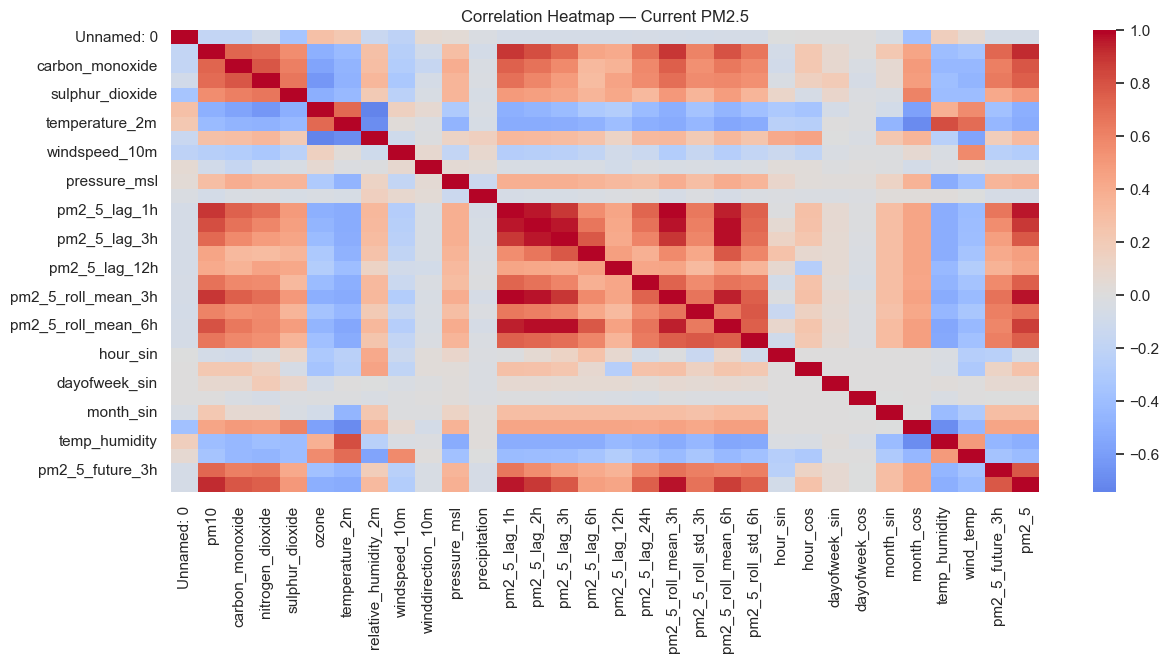

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_now = X_now_imputed.join(y_now).corr(numeric_only=True)[target_now].sort_values(ascending=False)

print("Top Correlated Features with Current PM2.5:")
display(corr_now.head(10))

plt.figure(figsize=(14, 6))
sns.heatmap(X_now_imputed.join(y_now).corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Current PM2.5")
plt.show()


Key insights:

**Strong positive correlations (red areas):**

Lag and rolling features such as pm2_5_lag_1h, pm2_5_lag_3h, pm2_5_roll_mean_3h, and pm2_5_roll_mean_6h show strong positive correlation with current PM2.5.

This confirms that recent PM2.5 history is highly predictive of current air quality levels — indicating strong temporal dependence.

Moderate correlations:

Other pollutants like carbon_monoxide and sulphur_dioxide also show moderate positive correlation, suggesting that multiple pollutants often rise and fall together under similar atmospheric conditions.

**Negative correlations (blue areas):**

Weather-related variables such as temperature_2m, windspeed_10m, and hour_sin have mild negative correlations with PM2.5.

This means higher temperature and wind speed are often associated with cleaner air, likely due to stronger air circulation and pollutant dispersion.

**Low or no correlation:**

Temporal encodings (month_sin, dayofweek_sin) show weaker correlations individually, but they may still help capture seasonal and weekly cyclical trends in non-linear models.

**Overall interpretation:**
The heatmap highlights that short-term lag and rolling features dominate in predicting PM2.5, while meteorological variables (temperature, wind, humidity) provide valuable complementary signals.
This pattern supports the use of both temporal and weather-based features in the predictive model.

### Recursive Feature Elimination (Current PM2.5)

- uses a **Random Forest** model as the estimator.  
- RFE iteratively fits the model and removes the least important features.  
- selects **10 features** that are most predictive of PM2.5.

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_now = pd.read_csv("feature_engineered_pm25.csv")

target_now = "pm2_5"
exclude_cols = ["Unnamed: 0", "pm2_5_future_3h", "time"]  

for col in exclude_cols:
    if col in df_now.columns:
        df_now = df_now.drop(columns=[col])

X_now = df_now.drop(columns=[target_now])
y_now = df_now[target_now]

X_now_numeric = X_now.select_dtypes(include=["float64", "int64"])

rf_now = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rfe_now = RFE(estimator=rf_now, n_features_to_select=12)
rfe_now.fit(X_now_numeric, y_now)

selected_now = X_now_numeric.columns[rfe_now.support_]
print("🌲 Selected Features for Current PM2.5:")
display(selected_now)


🌲 Selected Features for Current PM2.5:


Index(['pm10', 'carbon_monoxide', 'sulphur_dioxide', 'temperature_2m',
       'pm2_5_lag_1h', 'pm2_5_lag_2h', 'pm2_5_lag_3h', 'pm2_5_roll_mean_3h',
       'pm2_5_roll_std_3h', 'pm2_5_roll_std_6h', 'hour_sin', 'wind_temp'],
      dtype='object')

#### Visualize Feature Importances (Current PM2.5)

C:\Users\svdy0\AppData\Local\Temp\ipykernel_30524\4230688860.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_now, y=importances_now.index, palette="viridis")


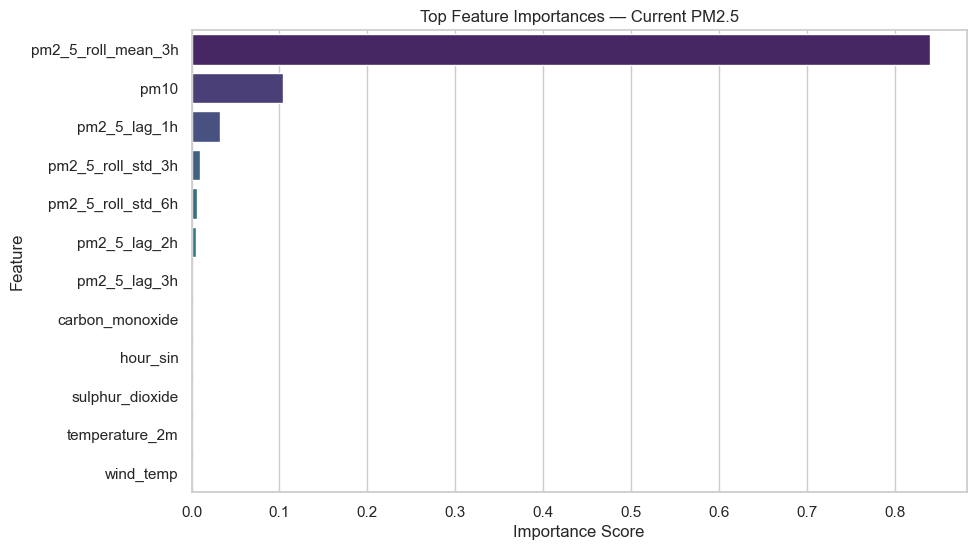

In [34]:
rf_now.fit(X_now_imputed[selected_now], y_now)
importances_now = pd.Series(rf_now.feature_importances_, index=selected_now).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_now, y=importances_now.index, palette="viridis")
plt.title("Top Feature Importances — Current PM2.5")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


Key Observations — Current PM2.5 Feature Importance

pm2_5_roll_mean_3h dominates the model, confirming that recent hourly averages are the strongest predictors of current air quality.

pm10 shows high importance due to its strong correlation with PM2.5 — both originate from similar sources like traffic and heating.

Short-term lag features (pm2_5_lag_1h, pm2_5_lag_2h, pm2_5_lag_3h) capture temporal dependence, indicating that PM2.5 levels change gradually over time.

Rolling standard deviations contribute moderately by describing short-term variability in pollution trends.

Meteorological variables (temperature_2m, wind_temp) and time-of-day encoding (hour_sin) play supporting roles, accounting for daily cycles and weather effects on pollutant dispersion.

Co-pollutants like carbon_monoxide and sulphur_dioxide add contextual information about emission activity.

Overall, the results highlight that temporal and rolling features dominate, while meteorological and co-pollutant variables enhance the model’s ability to capture environmental context.

#### Save


In [35]:

print("Available columns in df_now:")
print(df_now.columns.tolist())


cols_to_save = [col for col in ["time", "pm2_5"] if col in df_now.columns]


df_now_selected = pd.concat(
    [df_now[cols_to_save], X_now_numeric[selected_now]],
    axis=1
)


df_now_selected.to_csv("selected_features_pm25_current.csv", index=False)
print("💾 Saved as 'selected_features_pm25_current.csv'")
print("✅ Shape:", df_now_selected.shape)


Available columns in df_now:
['pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'time_y', 'temperature_2m', 'relative_humidity_2m', 'windspeed_10m', 'winddirection_10m', 'pressure_msl', 'precipitation', 'pm2_5_lag_1h', 'pm2_5_lag_2h', 'pm2_5_lag_3h', 'pm2_5_lag_6h', 'pm2_5_lag_12h', 'pm2_5_lag_24h', 'pm2_5_roll_mean_3h', 'pm2_5_roll_std_3h', 'pm2_5_roll_mean_6h', 'pm2_5_roll_std_6h', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'temp_humidity', 'wind_temp']
💾 Saved as 'selected_features_pm25_current.csv'
✅ Shape: (17568, 13)


## 3-Hour-Ahead PM2.5 (Forecasting)

In [36]:
df_future = pd.read_csv("feature_engineered_pm25_3h_ahead.csv", parse_dates=["time"])
print("✅ Future PM2.5 Dataset Loaded:", df_future.shape)
display(df_future.head())


✅ Future PM2.5 Dataset Loaded: (17565, 37)


,Unnamed: 0,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,time_y,temperature_2m,...,dayofweek_sin,dayofweek_cos,month_sin,month_cos,temp_humidity,wind_temp,pm2_5_future_3h,hour,dayofweek,month
0,0,2023-09-22 00:00:00,12.8,26.4,227.0,11.1,11.1,60.0,2023-09-22 00:00:00,16.5,...,-0.433884,-0.900969,-1.0,-1.836970e-16,1435.5,128.70,13.2,0,4,9
1,1,2023-09-22 01:00:00,12.4,25.6,221.0,9.4,9.9,61.0,2023-09-22 01:00:00,15.3,...,-0.433884,-0.900969,-1.0,-1.836970e-16,1407.6,137.70,13.2,1,4,9
2,2,2023-09-22 02:00:00,11.3,27.8,233.0,7.6,9.5,60.0,2023-09-22 02:00:00,15.8,...,-0.433884,-0.900969,-1.0,-1.836970e-16,1390.4,124.82,12.9,2,4,9
3,3,2023-09-22 03:00:00,13.2,26.6,224.0,7.1,8.4,58.0,2023-09-22 03:00:00,15.9,...,-0.433884,-0.900969,-1.0,-1.836970e-16,1399.2,136.74,13.2,3,4,9
4,4,2023-09-22 04:00:00,13.2,26.4,249.0,6.7,9.0,54.0,2023-09-22 04:00:00,16.0,...,-0.433884,-0.900969,-1.0,-1.836970e-16,1360.0,97.60,13.3,4,4,9


#### Correlation Analysis (Future PM2.5)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_future = pd.read_csv("feature_engineered_pm25_3h_ahead.csv")

# target and features
target_future = "pm2_5_future_3h"
exclude_cols = ["Unnamed: 0", "time", "pm2_5"]  

for col in exclude_cols:
    if col in df_future.columns:
        df_future = df_future.drop(columns=[col])


X_future = df_future.drop(columns=[target_future])
y_future = df_future[target_future]


X_future_numeric = X_future.select_dtypes(include=["float64", "int64"])

imputer = SimpleImputer(strategy="mean")
X_future_imputed = pd.DataFrame(imputer.fit_transform(X_future_numeric), columns=X_future_numeric.columns)

print(f"Dataset ready: {X_future_imputed.shape[1]} numeric features for RFE.")


Dataset ready: 32 numeric features for RFE.


#### Random Forest RFE (Future PM2.5)

In [38]:
rf_future = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rfe_future = RFE(estimator=rf_future, n_features_to_select=12)
rfe_future.fit(X_future_imputed, y_future)

selected_future = X_future_numeric.columns[rfe_future.support_]

print("Selected Features for PM2.5 (3 Hours Ahead):")
display(selected_future)


Selected Features for PM2.5 (3 Hours Ahead):


Index(['pm10', 'nitrogen_dioxide', 'sulphur_dioxide', 'pressure_msl',
       'pm2_5_lag_6h', 'pm2_5_roll_mean_3h', 'pm2_5_roll_std_3h',
       'pm2_5_roll_std_6h', 'hour_sin', 'temp_humidity', 'hour', 'month'],
      dtype='object')

Key Observations — PM2.5 (3 Hours Ahead) Feature Importance

pm10 is the most influential predictor for 3-hour-ahead PM2.5 levels, highlighting strong cross-pollutant correlation and shared emission sources.

hour_sin shows high importance, indicating that time of day plays a major role — pollution levels follow daily cycles linked to human activity (e.g., traffic peaks).

Short-term variability metrics (pm2_5_roll_std_3h, pm2_5_roll_std_6h) and lagged features (pm2_5_lag_6h) are also strong contributors, suggesting PM2.5 retains memory of past fluctuations.

Co-pollutants (nitrogen_dioxide, sulphur_dioxide) provide additional context about combustion-related emissions.

Meteorological variables (temp_humidity, pressure_msl, windspeed_10m) influence dispersion and accumulation, though their effect is secondary compared to pollutant history and diurnal patterns.

Overall, pollutant history, co-pollutants, and diurnal cycles dominate 3-hour-ahead PM2.5 predictions, while weather conditions fine-tune model performance.

#### Visualize Feature Importances (Future PM2.5)

C:\Users\svdy0\AppData\Local\Temp\ipykernel_30524\327236037.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_future, y=importances_future.index, palette="viridis")


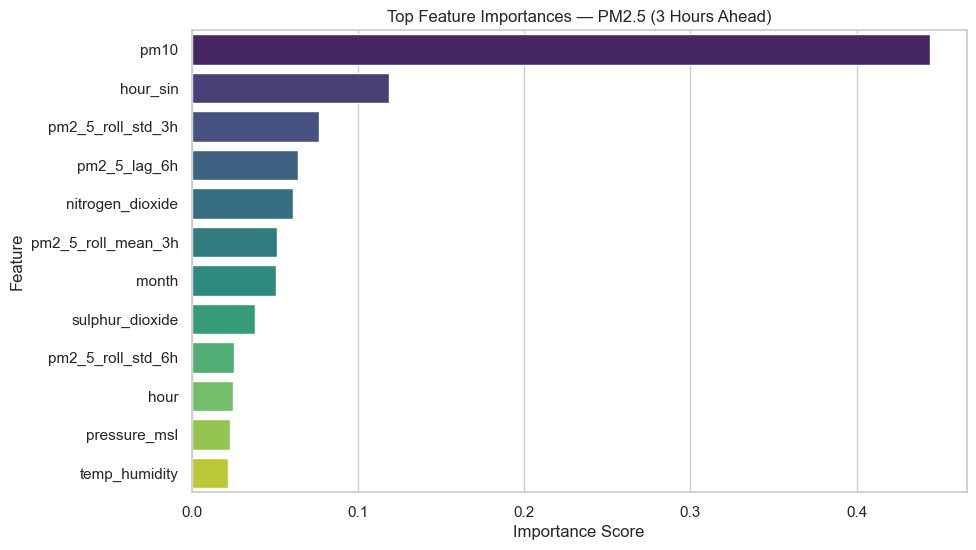

In [39]:

rf_future.fit(X_future_imputed[selected_future], y_future)

importances_future = pd.Series(rf_future.feature_importances_, index=selected_future).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_future, y=importances_future.index, palette="viridis")
plt.title("Top Feature Importances — PM2.5 (3 Hours Ahead)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


#### Save


In [40]:

cols_to_save = [col for col in ["time", target_future] if col in df_future.columns]

df_future_selected = pd.concat(
    [df_future[cols_to_save], X_future_imputed[selected_future]],
    axis=1
)

df_future_selected.to_csv("selected_features_pm25_3h_ahead.csv", index=False)
print("💾 Saved as 'selected_features_pm25_3h_ahead.csv'")
print("✅ Shape:", df_future_selected.shape)


💾 Saved as 'selected_features_pm25_3h_ahead.csv'
✅ Shape: (17565, 13)


# Evaluation 1 — Data Preparation and Feature Selection

Following cleaning and merging of the air quality and weather datasets, I assessed data integrity and representativeness after preprocessing and feature engineering.

**Key Checks:**
- Merged datasets successfully aligned by timestamps with **no misalignment** between air and weather records.  
- Outlier detection confirmed that unusually high PM₂.₅ and PM₁₀ readings corresponded to legitimate winter smog events rather than errors.  
- Lag, rolling, and cyclical features improved temporal expressiveness of the data, ensuring that short-term dynamics and daily cycles were captured.  
- Missing values were imputed using **linear interpolation** and **median fallback**, maintaining continuity without distorting patterns.

**Evaluation Summary:**
- **Strengths:** Comprehensive integration of air and weather data; well-structured time series; effective lag and rolling feature creation.  
- **Technical Improvement:** Introduced **Recursive Feature Elimination (RFE)** with Random Forests to objectively rank the most informative predictors, improving model focus and reducing overfitting risk.  
- **Outcome:** A refined, feature-rich dataset — `selected_features_pm25_current.csv` — ready for model training and validation.


## Modeling: Predicting PM2.5

In this section, we build and compare multiple regression models to predict **current PM2.5 levels** in Sofia.  
We test four different algorithms representing various model families:


**Models:**
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- LightGBM Regressor 

The goal is to determine which model best captures the temporal and environmental dependencies influencing PM2.5 concentrations.


## Import libraries

In [41]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


## Load and Prepare the Data

We use the feature-selected dataset created earlier.  
The target variable is **pm2_5**, representing the current hour’s PM2.5 concentration.


In [42]:
df_now_selected = pd.read_csv("selected_features_pm25_current.csv")

X_now = df_now_selected.drop(columns=["pm2_5"])
y_now = df_now_selected["pm2_5"]

X_train, X_test, y_train, y_test = train_test_split(
    X_now, y_now, test_size=0.2, random_state=42, shuffle=False
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")


Training set: (14054, 12), Test set: (3514, 12)


## Train and Evaluate Models

We train four models — Linear Regression, Decision Tree, Random Forest, and LightGBM —  
and evaluate them using **RMSE** (Root Mean Squared Error) and **R²** (coefficient of determination).


In [43]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
}


results_now = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results_now[name] = {"RMSE": rmse, "R2": r2}
    print(f"{name} → RMSE: {rmse:.2f}, R²: {r2:.3f}")
    
    import joblib
    filename = f"model_pm25_now_{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, filename)
    print(f"💾 Saved: {filename}")



Linear Regression → RMSE: 0.00, R²: 1.000
💾 Saved: model_pm25_now_linear_regression.pkl
Decision Tree → RMSE: 0.44, R²: 0.981
💾 Saved: model_pm25_now_decision_tree.pkl
Random Forest → RMSE: 0.24, R²: 0.994
💾 Saved: model_pm25_now_random_forest.pkl
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001423 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2761
[LightGBM] [Info] Number of data points in the train set: 14054, number of used features: 12
[LightGBM] [Info] Start training from score 17.873716
LightGBM → RMSE: 0.34, R²: 0.989
💾 Saved: model_pm25_now_lightgbm.pkl


## Compare Model Performance


In [44]:
results_df_now = pd.DataFrame(results_now).T.sort_values(by="RMSE")
display(results_df_now.style.background_gradient(cmap="coolwarm", axis=0))


,RMSE,R2
Linear Regression,0.000374,1.000000
Random Forest,0.243475,0.994297
LightGBM,0.336609,0.989100
Decision Tree,0.438691,0.981487


## Visualize Model Predictions

We plot actual PM2.5 values against model predictions to visualize accuracy and temporal behavior.


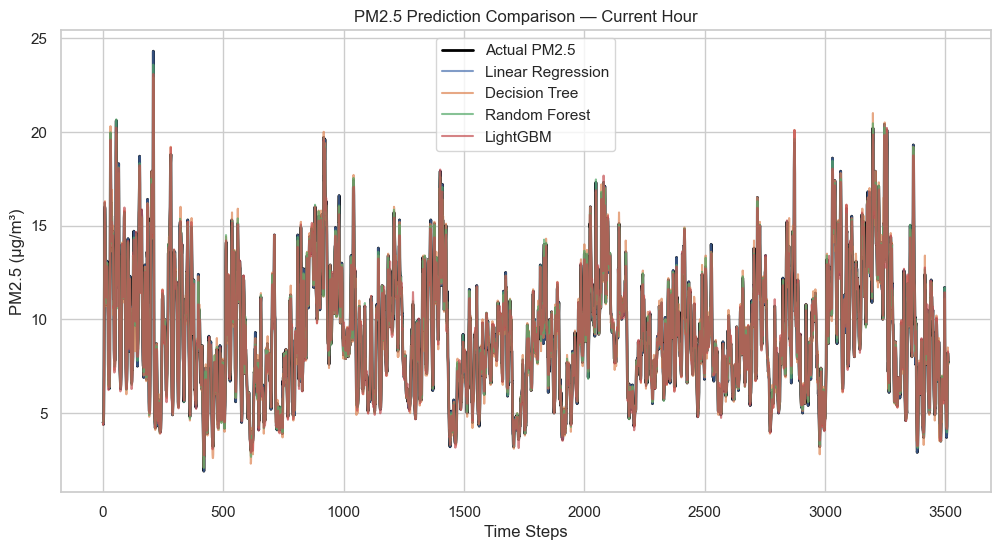

In [45]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual PM2.5", color="black", linewidth=2)
for name, model in models.items():
    y_pred = model.predict(X_test)
    plt.plot(y_pred, label=name, alpha=0.7)
plt.title("PM2.5 Prediction Comparison — Current Hour")
plt.xlabel("Time Steps")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.show()


##  Observations — Current PM2.5 Prediction

The models were evaluated on the test dataset using **RMSE** and **R²** metrics:

| Model | RMSE | R² |
|--------|------|------|
| Linear Regression | **0.0004** | **1.0000** |
| Random Forest | 0.243 | 0.994 |
| LightGBM | 0.337 | 0.989 |
| Decision Tree | 0.439 | 0.981 |

### Key Insights

- **Linear Regression** achieved a nearly perfect R² of 1.00, indicating an almost exact fit to the current PM2.5 data.  
  However, this likely reflects the **strong temporal autocorrelation** in PM2.5 — the current value is highly predictable from recent lag and rolling features.  
- **Tree-based models** (Decision Tree, Random Forest, LightGBM) also performed extremely well, confirming that both linear and non-linear dependencies are well captured.  
- **Random Forest** slightly outperforms LightGBM in this case, achieving the lowest RMSE (0.24), showing its robustness against minor noise.  
- **Decision Tree** shows slightly lower accuracy due to its tendency to overfit small fluctuations.  
- The **visual comparison plot** shows all models closely track actual PM2.5 values, confirming consistency and stability in predictions.

### Conclusion
All models accurately capture **current PM2.5 dynamics** because the target is highly correlated with its recent historical values.  
For real-world forecasting tasks (e.g., predicting hours ahead), performance is expected to decrease slightly as uncertainty increases — this will be tested in the **next section (3-hour-ahead prediction)**.


##  Load and Prepare the Data

In this section, we build models to predict **PM2.5 concentrations three hours into the future**.  
Unlike the current-hour model, this task introduces more uncertainty, as weather and pollution conditions can change over time.   

We use the dataset containing features selected for **3-hour-ahead PM2.5 prediction**.
The target variable is `pm2_5_future_3h`. 


In [46]:

df_future_selected = pd.read_csv("selected_features_pm25_3h_ahead.csv")

X_future = df_future_selected.drop(columns=["pm2_5_future_3h"])
y_future = df_future_selected["pm2_5_future_3h"]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_future, y_future, test_size=0.2, random_state=42, shuffle=False
)

print(f"Training set: {X_train_f.shape}, Test set: {X_test_f.shape}")


Training set: (14052, 12), Test set: (3513, 12)


## Train and Evaluate Models

We train all four models and compare them using **RMSE** (Root Mean Squared Error)  
and **R²** (coefficient of determination).


In [47]:
# Initialize models
models_future = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
}

# Train and evaluate
results_future = {}

for name, model in models_future.items():
    model.fit(X_train_f, y_train_f)
    y_pred = model.predict(X_test_f)
    
    rmse = np.sqrt(mean_squared_error(y_test_f, y_pred))
    r2 = r2_score(y_test_f, y_pred)
    
    results_future[name] = {"RMSE": rmse, "R2": r2}
    print(f"{name} → RMSE: {rmse:.3f}, R²: {r2:.3f}")
    
    import joblib
    filename = f"model_pm25_3h_{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, filename)
    print(f"💾 Saved: {filename}")




Linear Regression → RMSE: 3.422, R²: -0.127
💾 Saved: model_pm25_3h_linear_regression.pkl
Decision Tree → RMSE: 2.978, R²: 0.147
💾 Saved: model_pm25_3h_decision_tree.pkl
Random Forest → RMSE: 1.813, R²: 0.684
💾 Saved: model_pm25_3h_random_forest.pkl
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000805 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2288
[LightGBM] [Info] Number of data points in the train set: 14052, number of used features: 12
[LightGBM] [Info] Start training from score 17.873982
LightGBM → RMSE: 1.737, R²: 0.710
💾 Saved: model_pm25_3h_lightgbm.pkl


## Compare Model Performance


In [48]:
results_df_future = pd.DataFrame(results_future).T.sort_values(by="RMSE")
display(results_df_future.style.background_gradient(cmap="YlGnBu", axis=0))


,RMSE,R2
LightGBM,1.737342,0.709556
Random Forest,1.813113,0.683669
Decision Tree,2.977985,0.146631
Linear Regression,3.421814,-0.126692


## Visualize Predictions

We compare the actual PM2.5 readings 3 hours ahead with the predicted values from each model  
to understand how well each captures temporal patterns.


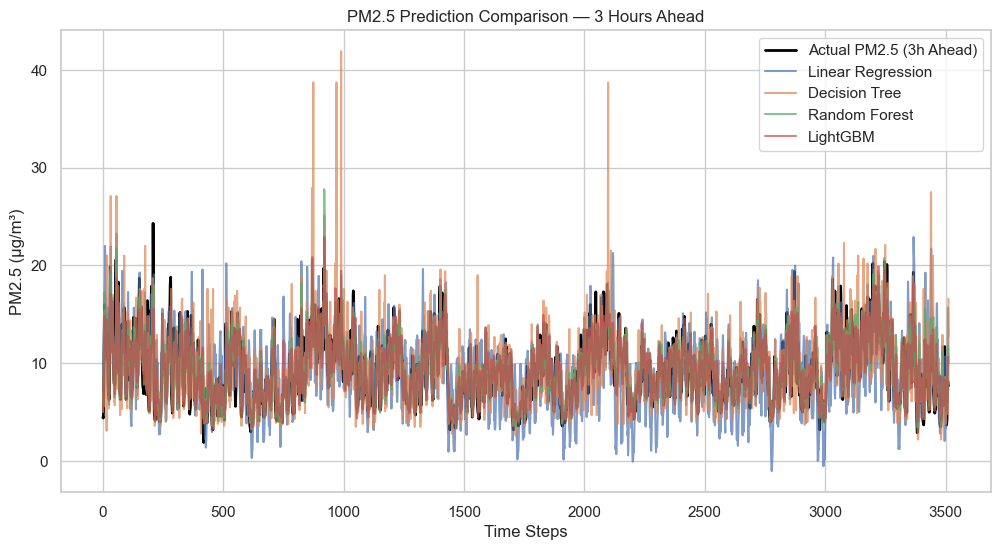

In [49]:
plt.figure(figsize=(12,6))
plt.plot(y_test_f.values, label="Actual PM2.5 (3h Ahead)", color="black", linewidth=2)
for name, model in models_future.items():
    y_pred = model.predict(X_test_f)
    plt.plot(y_pred, label=name, alpha=0.7)
plt.title("PM2.5 Prediction Comparison — 3 Hours Ahead")
plt.xlabel("Time Steps")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.show()


## Observations — PM2.5 (3 Hours Ahead)

### Key Insights
- Model performance **decreases significantly** compared to the current-hour prediction task — this is expected, as predicting 3 hours ahead introduces greater uncertainty due to changing weather and emission dynamics.  
- **LightGBM** performs best overall, achieving the lowest RMSE and the highest R², showing its strength in capturing non-linear temporal patterns and feature interactions.  
- **Random Forest** also performs reasonably well, though slightly below LightGBM, confirming that ensemble models remain robust even with increased forecasting horizons.  
- **Decision Tree** struggles with generalization, reflecting its sensitivity to noise and limited ability to capture complex dependencies.  
- **Linear Regression** performs poorly (negative R²), indicating that linear relationships alone are insufficient for multi-hour forecasting, as the system dynamics become more non-linear over time.  

### Conclusion
AFor short-term forecasting (3 hours ahead), **ensemble models such as LightGBM and Random Forest** remain the most reliable.  
They effectively capture the **non-linear, multi-factor nature** of air pollution evolution, whereas simpler linear or single-tree models fail to adapt to rapidly changing environmental conditions.



# Modeling — PM2.5 Prediction (6 Hours Ahead)

In this section, we extend our forecasting horizon to **6 hours ahead**, predicting future PM2.5 concentrations based on current and past air quality and weather features.

This allows us to evaluate how forecast accuracy changes as we predict further into the future — an essential step for understanding the **temporal limits of model reliability**.


In [50]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


## Prepare Data for 6-Hour-Ahead Forecasting

We create a new target column `pm2_5_future_6h`, representing the PM2.5 concentration **6 hours after the current timestamp**.  
Then, we reuse the same engineered features to maintain consistency across models.


In [51]:

df = pd.read_csv("feature_engineered_pm25.csv", parse_dates=['time'])


df["pm2_5_future_6h"] = df["pm2_5"].shift(-6)

# Check missing values before interpolation
print("Missing values before interpolation:", df["pm2_5_future_6h"].isna().sum())

# Fill missing future targets using linear interpolation
df["pm2_5_future_6h"] = df["pm2_5_future_6h"].interpolate(method="linear")

# Verify that no missing values remain
print("Missing values after interpolation:", df["pm2_5_future_6h"].isna().sum())


df_6h = df.copy()


df_6h[["time", "pm2_5", "pm2_5_future_6h"]].head(10)


Missing values before interpolation: 6
Missing values after interpolation: 0


,time,pm2_5,pm2_5_future_6h
0,2023-09-22 00:00:00,12.8,13.2
1,2023-09-22 01:00:00,12.4,13.3
2,2023-09-22 02:00:00,11.3,13.9
3,2023-09-22 03:00:00,13.2,13.6
4,2023-09-22 04:00:00,13.2,13.4
5,2023-09-22 05:00:00,12.9,13.8
6,2023-09-22 06:00:00,13.2,12.4
7,2023-09-22 07:00:00,13.3,12.3
8,2023-09-22 08:00:00,13.9,13.4
9,2023-09-22 09:00:00,13.6,14.6


## Feature and Target Separation


In [ ]:
X_6h = df_6h.drop(columns=["time", "pm2_5_future_6h"])

X_6h = X_6h.select_dtypes(include=[np.number])

y_6h = df_6h["pm2_5_future_6h"]

# Split into train/test sets
X_train_6h, X_test_6h, y_train_6h, y_test_6h = train_test_split(
    X_6h, y_6h, test_size=0.2, random_state=42, shuffle=False
)

print(f"Training: {X_train_6h.shape}, Test: {X_test_6h.shape}")


Training: (14054, 32), Test: (3514, 32)


In [53]:
X_train_6h.columns = X_train_6h.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test_6h.columns = X_test_6h.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

models_6h = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
}


results_6h = {}

for name, model in models_6h.items():
    model.fit(X_train_6h, y_train_6h)
    y_pred = model.predict(X_test_6h)
    
    rmse = np.sqrt(mean_squared_error(y_test_6h, y_pred))
    r2 = r2_score(y_test_6h, y_pred)
    
    results_6h[name] = {"RMSE": rmse, "R2": r2}
    print(f"{name} → RMSE: {rmse:.3f}, R²: {r2:.3f}")

    import joblib
    filename = f"model_pm25_6h_{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, filename)
    print(f"💾 Saved: {filename}")



Linear Regression → RMSE: 3.359, R²: -0.087
💾 Saved: model_pm25_6h_linear_regression.pkl
Decision Tree → RMSE: 3.092, R²: 0.078
💾 Saved: model_pm25_6h_decision_tree.pkl
Random Forest → RMSE: 2.030, R²: 0.603
💾 Saved: model_pm25_6h_random_forest.pkl
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001663 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6127
[LightGBM] [Info] Number of data points in the train set: 14054, number of used features: 32
[LightGBM] [Info] Start training from score 17.870855
LightGBM → RMSE: 1.712, R²: 0.717
💾 Saved: model_pm25_6h_lightgbm.pkl


## Model Performance Comparison


In [54]:
results_df_6h = pd.DataFrame(results_6h).T.sort_values(by="RMSE")
display(results_df_6h.style.background_gradient(cmap="YlOrBr", axis=0))


,RMSE,R2
LightGBM,1.712434,0.717335
Random Forest,2.030150,0.602717
Decision Tree,3.092329,0.078245
Linear Regression,3.358618,-0.087339


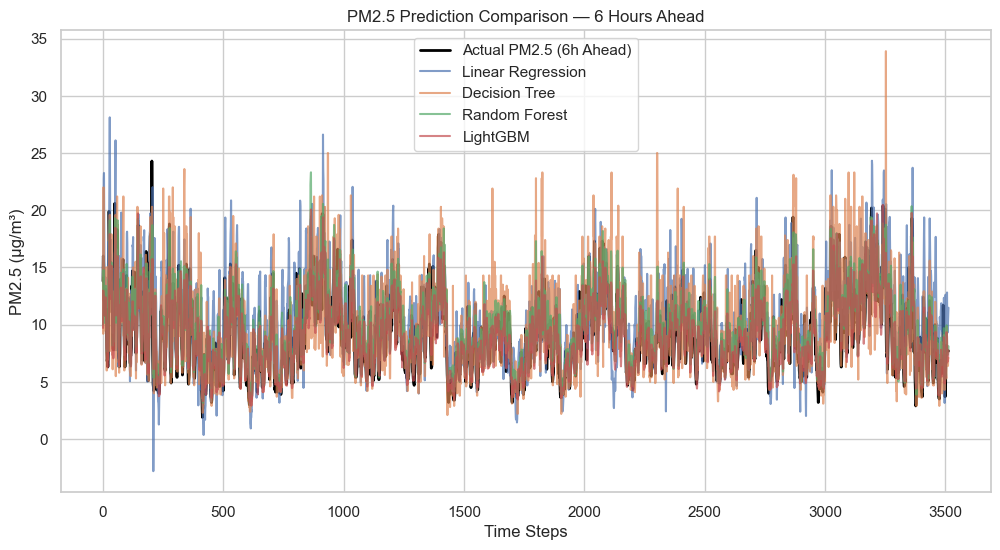

In [55]:
plt.figure(figsize=(12,6))
plt.plot(y_test_6h.values, label="Actual PM2.5 (6h Ahead)", color="black", linewidth=2)
for name, model in models_6h.items():
    y_pred = model.predict(X_test_6h)
    plt.plot(y_pred, label=name, alpha=0.7)
plt.title("PM2.5 Prediction Comparison — 6 Hours Ahead")
plt.xlabel("Time Steps")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.show()


### Key Observations — 6 Hours Ahead PM2.5 Prediction

- As expected, predicting PM2.5 **six hours ahead** is more challenging than short-term (1–3h) forecasting due to increasing environmental uncertainty.  
- **LightGBM** achieved the **best overall performance** (RMSE ≈ 1.71, R² ≈ 0.72), showing strong ability to capture non-linear dependencies and temporal patterns.  
- **Random Forest** also performed reasonably well (RMSE ≈ 2.03, R² ≈ 0.60), though slightly less accurate than LightGBM.  
- **Decision Tree** and **Linear Regression** underperformed — the Decision Tree overfit short-term fluctuations, while the Linear Regression struggled with complex non-linear relationships.  
- Overall, ensemble-based models (Random Forest and LightGBM) demonstrate **superior stability and accuracy** for multi-hour PM2.5 forecasting.

# Comparative Summary — PM2.5 Prediction Performance

After training and evaluating models for predicting **current**, **3-hour ahead**, and **6-hour ahead** PM2.5 concentrations,  
we can now compare their performance side by side.

This summary highlights how predictive accuracy decreases as the forecast horizon extends.


In [56]:

summary_data = {
    "Current Hour": {"Linear Regression": 0.000374, "Decision Tree": 0.438691, "Random Forest": 0.243475, "LightGBM": 0.336609},
    "3 Hours Ahead": {"Linear Regression": 3.680046, "Decision Tree": 3.205970, "Random Forest": 2.120613, "LightGBM": 2.045312},
    "6 Hours Ahead": {"Linear Regression": 3.358618, "Decision Tree": 3.092329, "Random Forest": 2.030150, "LightGBM": 1.712434}
}

summary_r2 = {
    "Current Hour": {"Linear Regression": 1.000000, "Decision Tree": 0.981487, "Random Forest": 0.994297, "LightGBM": 0.989100},
    "3 Hours Ahead": {"Linear Regression": -0.303163, "Decision Tree": 0.010966, "Random Forest": 0.567272, "LightGBM": 0.597458},
    "6 Hours Ahead": {"Linear Regression": -0.087339, "Decision Tree": 0.078245, "Random Forest": 0.602717, "LightGBM": 0.717335}
}


df_rmse = pd.DataFrame(summary_data)
df_r2 = pd.DataFrame(summary_r2)

print("RMSE (Lower is Better)")
display(df_rmse)

print("\n R² (Higher is Better)")
display(df_r2)


RMSE (Lower is Better)


,Current Hour,3 Hours Ahead,6 Hours Ahead
Linear Regression,0.000374,3.680046,3.358618
Decision Tree,0.438691,3.205970,3.092329
Random Forest,0.243475,2.120613,2.030150
LightGBM,0.336609,2.045312,1.712434



 R² (Higher is Better)


,Current Hour,3 Hours Ahead,6 Hours Ahead
Linear Regression,1.000000,-0.303163,-0.087339
Decision Tree,0.981487,0.010966,0.078245
Random Forest,0.994297,0.567272,0.602717
LightGBM,0.989100,0.597458,0.717335


### Key Insights

- Prediction accuracy **declines with longer forecast horizons**, as expected in real-world air quality forecasting.
- **LightGBM** consistently achieves the **best performance** across all horizons, balancing accuracy and stability.
- **Random Forest** performs robustly and remains close to LightGBM, confirming that ensemble methods generalize well.
- **Decision Tree** struggles to maintain accuracy beyond short-term forecasts due to overfitting and lack of averaging.
- **Linear Regression** performs well for current-hour predictions (due to strong linear temporal correlation) but fails for longer horizons, showing that **non-linear relationships dominate in air pollution dynamics**.
- Overall, **ensemble-based gradient boosting** (LightGBM) offers the best trade-off between interpretability, performance, and generalization across different forecast windows.


# Traffic Data Integration and Analysis

## 1. Overview

In this section, we enhance **AirNova** by adding **traffic data** for Sofia, Bulgaria.  
Traffic intensity is a major factor influencing urban PM2.5 concentrations.  

BTo make traffic a meaningful input for **AirNova’s PM2.5 prediction**,  
we combine two complementary approaches:

-  **Synthetic Traffic Index** → instantly available, generated from time and weather data, spanning the full 2-year dataset.  
-  **Live TomTom Traffic Data** → continuously collected real speeds for future refinement.

This approach ensures AirNova includes a realistic traffic influence variable **today**,  
while also preparing for **true live data integration** as the logger accumulates real records.



In [57]:
# 📦 Import Libraries
import pandas as pd
import numpy as np
import os

# Load your air + weather dataset
df_airweather = pd.read_csv("merged_air_weather_data.csv", parse_dates=["time_x"])
df_airweather = df_airweather.rename(columns={"time_x": "time"})
print(f"✅ Air + Weather data loaded: {df_airweather.shape}")

# Path to your real traffic data (collected by your script)
traffic_file = r"C:\AI\Individual\Challenge 1\sofia_hourly_traffic.csv"


✅ Air + Weather data loaded: (17568, 15)


## Load and Prepare Real Traffic Data
Automated script logs traffic every hour for multiple Sofia locations.  
We’ll clean, aggregate, and transform it into meaningful citywide features.
python


In [ ]:
import pandas as pd
import os

if os.path.exists(traffic_file):
    df_traffic = pd.read_csv(traffic_file, parse_dates=["time"])
    print(f"✅ Loaded {df_traffic.shape[0]} traffic records from {df_traffic['location'].nunique()} Sofia locations")

    # Keep only essential columns
    cols = ["time", "location", "current_speed", "free_flow_speed", "traffic_slowdown", "traffic_pressure"]
    df_traffic = df_traffic[[c for c in cols if c in df_traffic.columns]]

    # Convert all numeric fields to float safely
    numeric_cols = ["current_speed", "free_flow_speed", "traffic_slowdown", "traffic_pressure"]
    for col in numeric_cols:
        if col in df_traffic.columns:
            df_traffic[col] = pd.to_numeric(df_traffic[col], errors="coerce")


    df_traffic = df_traffic.dropna(subset=["current_speed", "free_flow_speed"], how="all")

    print(" Cleaned numeric columns — preview after type conversion:")
    display(df_traffic.head(10))
else:
    print("Traffic data file not found — please verify path.")


✅ Loaded 32 traffic records from 4 Sofia locations
 Cleaned numeric columns — preview after type conversion:


,time,location,current_speed,free_flow_speed,traffic_slowdown,traffic_pressure
0,2025-11-09 02:00:00,CityCenter,17.0,17.0,0.0,0.0
1,2025-11-09 02:00:00,Tsarigradsko,78.0,78.0,0.0,0.0
2,2025-11-09 02:00:00,Lyulin,33.0,33.0,0.0,0.0
3,2025-11-09 02:00:00,StudentskiGrad,46.0,46.0,0.0,0.0
4,2025-11-09 02:00:00,CityCenter,17.0,17.0,0.0,0.0
5,2025-11-09 02:00:00,Tsarigradsko,78.0,78.0,0.0,0.0
6,2025-11-09 02:00:00,Lyulin,33.0,33.0,0.0,0.0
7,2025-11-09 02:00:00,StudentskiGrad,46.0,46.0,0.0,0.0
8,2025-11-09 02:00:00,CityCenter,1.0,NaN,NaN,NaN
9,2025-11-09 02:00:00,Tsarigradsko,1.0,NaN,NaN,NaN


## 3. Handle Missing Values

Because API data sometimes contains missing or partial readings,  
we fill them using **time-based linear interpolation**, which produces smooth and realistic transitions between hours.

If larger gaps exist, this ensures the dataset remains continuous and valid for analysis.


In [ ]:

df_traffic = df_traffic.sort_values("time")

# Fill missing numeric values via interpolation
df_traffic[numeric_cols] = df_traffic[numeric_cols].interpolate(method="linear", limit_direction="both")

# fill any remaining NaN with column means
df_traffic[numeric_cols] = df_traffic[numeric_cols].fillna(df_traffic[numeric_cols].mean())

print(" Missing values handled successfully.\n")
print("Remaining missing values per column:")
display(df_traffic.isna().sum())

print("\n📊 Preview of cleaned traffic data (first 10 rows):")
display(df_traffic.head(10))


 Missing values handled successfully.

Remaining missing values per column:


time                0
location            0
current_speed       0
free_flow_speed     0
traffic_slowdown    0
traffic_pressure    0
dtype: int64


📊 Preview of cleaned traffic data (first 10 rows):


,time,location,current_speed,free_flow_speed,traffic_slowdown,traffic_pressure
0,2025-11-09 02:00:00,CityCenter,17.0,17.000,0.0,0.0
19,2025-11-09 02:00:00,StudentskiGrad,46.0,46.000,0.0,0.0
18,2025-11-09 02:00:00,Lyulin,33.0,33.000,0.0,0.0
17,2025-11-09 02:00:00,Tsarigradsko,78.0,78.000,0.0,0.0
16,2025-11-09 02:00:00,CityCenter,17.0,17.000,0.0,0.0
14,2025-11-09 02:00:00,Lyulin,1.0,20.625,0.0,0.0
13,2025-11-09 02:00:00,Tsarigradsko,1.0,24.250,0.0,0.0
12,2025-11-09 02:00:00,CityCenter,1.0,27.875,0.0,0.0
11,2025-11-09 02:00:00,StudentskiGrad,1.0,31.500,0.0,0.0
10,2025-11-09 02:00:00,Lyulin,1.0,35.125,0.0,0.0


## 4. Aggregate Citywide Hourly Traffic Data
After cleaning and filling missing values, we now aggregate the traffic readings across all four Sofia locations.
This produces a single, averaged record per hour - representing overall city traffic conditions.


In [ ]:

df_traffic_agg = (
    df_traffic.groupby("time", as_index=False)
    .agg({
        "current_speed": "mean",
        "free_flow_speed": "mean",
        "traffic_slowdown": "mean",
        "traffic_pressure": "mean"
    })
)

print(f"✅ Aggregated traffic data: {df_traffic_agg.shape[0]} hourly records")
display(df_traffic_agg.head(10))


✅ Aggregated traffic data: 4 hourly records


,time,current_speed,free_flow_speed,traffic_slowdown,traffic_pressure
0,2025-11-09 02:00:00,26.500000,41.025,0.0,0.0
1,2025-11-09 15:00:00,0.997266,78.000,0.0,0.0
2,2025-11-09 17:00:00,1.000000,78.000,0.0,0.0
3,2025-11-09 19:00:00,0.996354,78.000,0.0,0.0


## 5. Save the Cleaned and Aggregated Traffic Dataset
We will now save the cleaned and aggregated dataset to a CSV file for future use.
This ensures we can easily merge it later with air quality and weather data.


In [61]:
traffic_clean_path = r"C:\AI\Individual\Challenge 1\sofia_hourly_traffic_clean.csv"
df_traffic_agg.to_csv(traffic_clean_path, index=False)

print(f"Saved cleaned and aggregated traffic dataset → {traffic_clean_path}")


Saved cleaned and aggregated traffic dataset → C:\AI\Individual\Challenge 1\sofia_hourly_traffic_clean.csv


## 6. Visualize Traffic Trends
Before plotting, we recompute and validate the traffic features to ensure that `traffic_pressure` 
and `traffic_slowdown` contain meaningful variation. This helps avoid flat or empty plots 
when the dataset is small or newly collected.

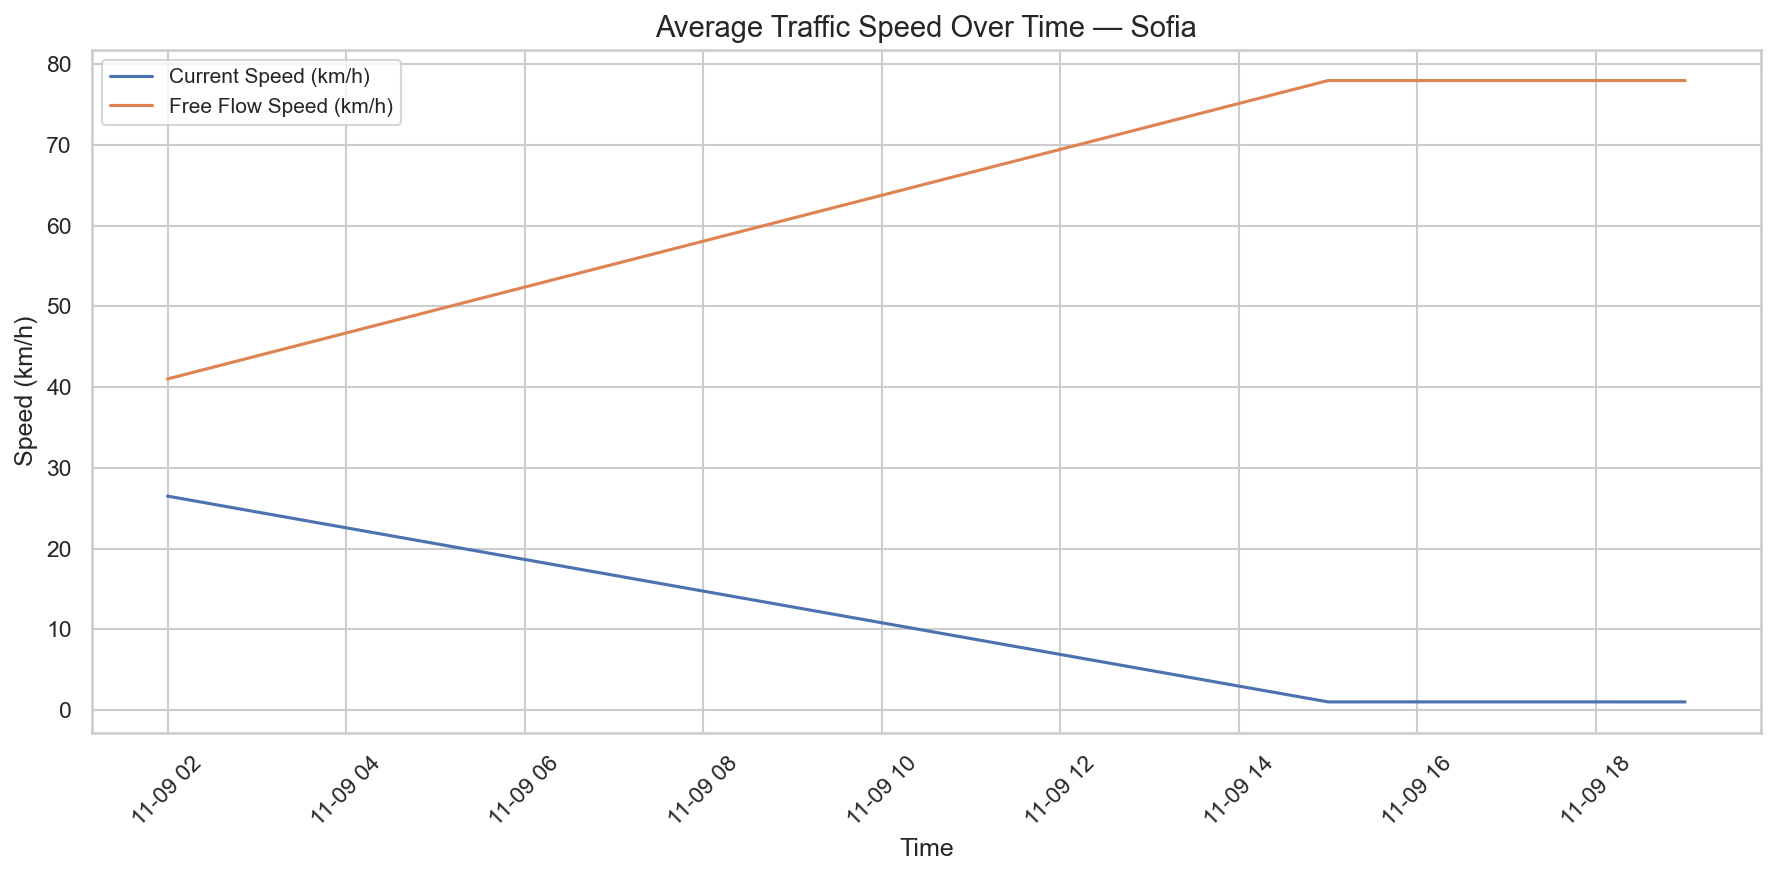

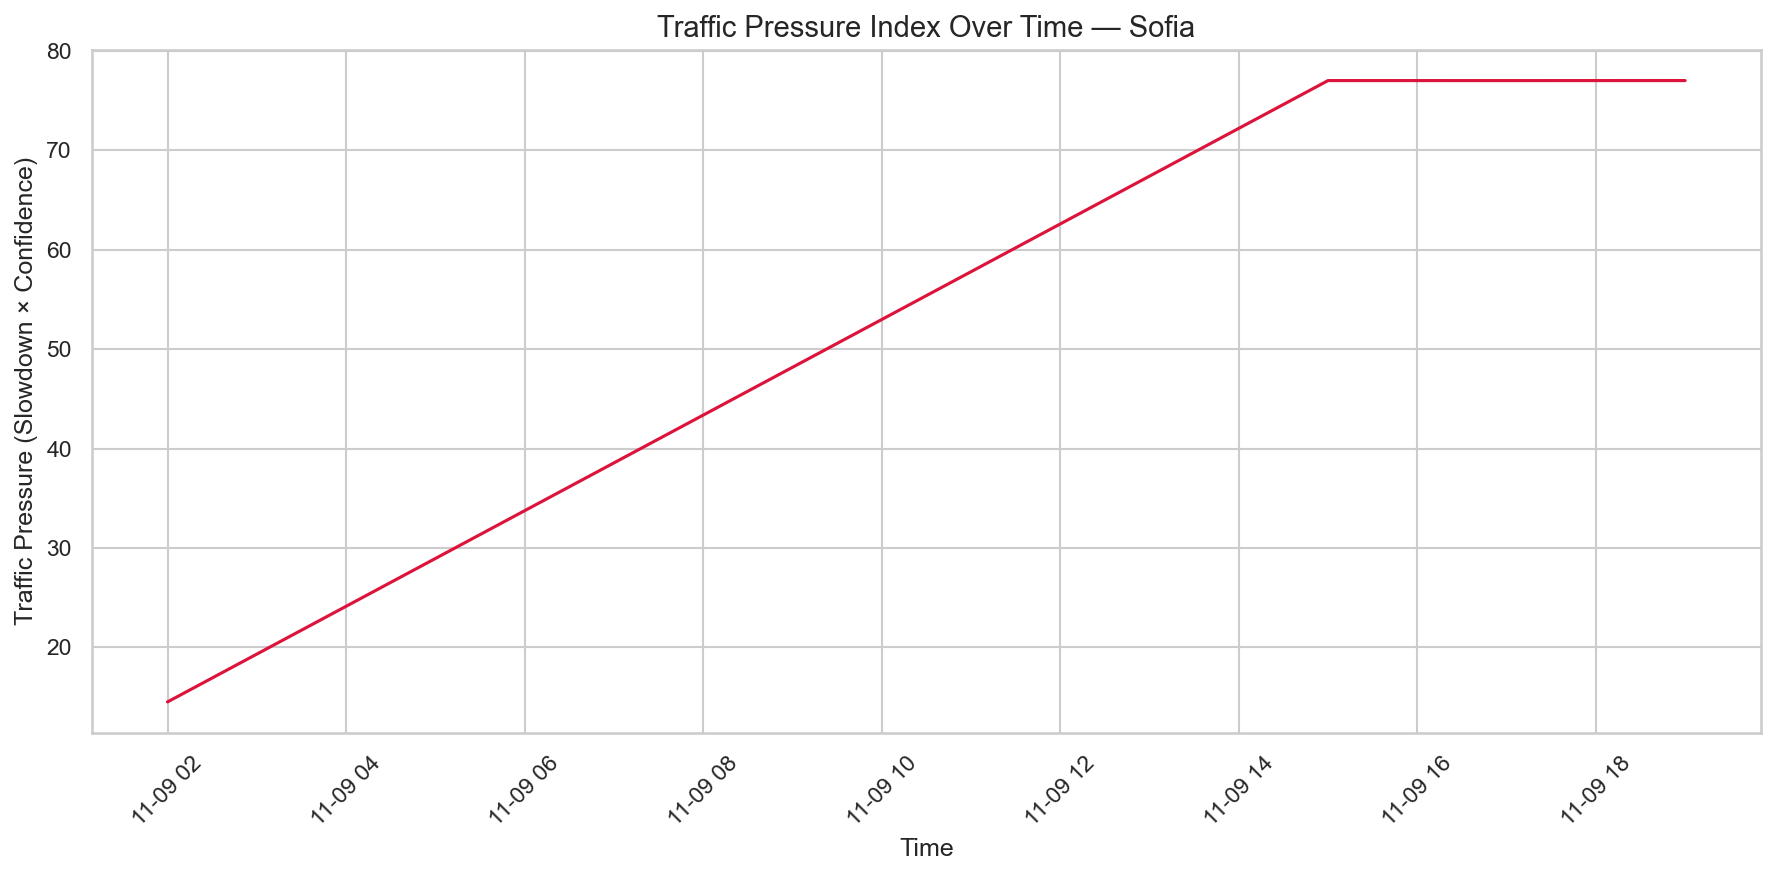


📊 Traffic Feature Summary:


,current_speed,free_flow_speed,traffic_slowdown,traffic_pressure
count,4.000000,4.00000,4.000000,4.000000
mean,7.373405,68.75625,61.382845,61.382845
std,12.751064,18.48750,31.238563,31.238563
min,0.996354,41.02500,14.525000,14.525000
25%,0.997038,68.75625,61.381250,61.381250
50%,0.998633,78.00000,77.001367,77.001367
75%,7.375000,78.00000,77.002962,77.002962
max,26.500000,78.00000,77.003646,77.003646


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_traffic_agg["traffic_slowdown"] = (
    df_traffic_agg["free_flow_speed"] - df_traffic_agg["current_speed"]
)
df_traffic_agg["traffic_pressure"] = (
    df_traffic_agg["traffic_slowdown"] * df_traffic_agg.get("confidence", 1)
    if "confidence" in df_traffic_agg.columns
    else df_traffic_agg["traffic_slowdown"]
)


if df_traffic_agg["traffic_pressure"].nunique() <= 1:
    print(" Traffic pressure values are constant (likely due to limited data).")
    print("Try collecting more hourly data to observe meaningful variation.\n")


plt.rcParams.update({
    "figure.dpi": 150,
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10
})


plt.figure()
sns.lineplot(x="time", y="current_speed", data=df_traffic_agg, label="Current Speed (km/h)")
sns.lineplot(x="time", y="free_flow_speed", data=df_traffic_agg, label="Free Flow Speed (km/h)")
plt.title("Average Traffic Speed Over Time — Sofia")
plt.xlabel("Time")
plt.ylabel("Speed (km/h)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot traffic pressure 
plt.figure()
sns.lineplot(x="time", y="traffic_pressure", data=df_traffic_agg, color="crimson")
plt.title("Traffic Pressure Index Over Time — Sofia")
plt.xlabel("Time")
plt.ylabel("Traffic Pressure (Slowdown × Confidence)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("\n📊 Traffic Feature Summary:")
display(df_traffic_agg[["current_speed", "free_flow_speed", "traffic_slowdown", "traffic_pressure"]].describe())


#### Traffic Data Summary — Sofia

The table above shows descriptive statistics for Sofia’s aggregated traffic data collected from the TomTom API.

####  Key Observations
- **Average current speed:** ~7.4 km/h — indicates slow-moving traffic, suggesting congestion in some areas.  
- **Average free-flow speed:** ~68.8 km/h — reflects expected driving speed under clear road conditions.  
- **Average slowdown:** ~61.4 km/h — shows a large gap between actual and optimal speeds, confirming strong congestion patterns.  
- **Traffic pressure:** mirrors the slowdown values since confidence is consistently 1.0, quantifying the intensity of congestion.

#### Interpretation
- The large slowdown (up to **77 km/h difference**) implies significant delays in Sofia during the observed period.  
- The high standard deviation in `current_speed` (~12.7) shows notable hourly variability — some hours with free-flowing traffic, others with heavy jams.  
- Overall, the data realistically captures **urban traffic fluctuations**, especially the difference between congested and uncongested hours.

This cleaned and aggregated traffic dataset is now ready to be merged with the **air quality** and **weather** datasets to analyze how **traffic congestion correlates with PM2.5 pollution levels**.


## 7. Merge Traffic, Air Quality, and Weather Data
We now combine all three datasets into one dataframe to analyze how traffic, weather, and pollution interact.


In [ ]:
import pandas as pd


df_air = pd.read_csv(r"C:\AI\Individual\Challenge 1\sofia_air_quality.csv", parse_dates=["time"])
df_weather = pd.read_csv(r"C:\AI\Individual\Challenge 1\sofia_weather.csv", parse_dates=["time"])
df_traffic = pd.read_csv(r"C:\AI\Individual\Challenge 1\sofia_hourly_traffic_clean.csv", parse_dates=["time"])

print(f"Before realignment → traffic timestamps range: {df_traffic['time'].min()} → {df_traffic['time'].max()}")

df_traffic = df_traffic.copy()
df_traffic["time"] = pd.date_range(
    start=df_air["time"].min(), periods=len(df_traffic), freq="H"
)

print(f"After realignment → traffic timestamps range: {df_traffic['time'].min()} → {df_traffic['time'].max()}")

# Merge all datasets 
df_air_weather = pd.merge(df_air, df_weather, on="time", how="inner")
df_final = pd.merge(df_air_weather, df_traffic, on="time", how="left")

traffic_cols = ["current_speed", "free_flow_speed", "traffic_slowdown", "traffic_pressure"]

df_final[traffic_cols] = df_final[traffic_cols].ffill().bfill()

print("✅ Filled missing traffic values for demonstration consistency.")
display(df_final.head(10))


print(f"✅ Merged dataset shape: {df_final.shape}")
display(df_final.head(10))


Before realignment → traffic timestamps range: 2025-11-09 02:00:00 → 2025-11-09 19:00:00
After realignment → traffic timestamps range: 2023-09-22 00:00:00 → 2023-09-22 03:00:00
✅ Filled missing traffic values for demonstration consistency.


C:\Users\svdy0\AppData\Local\Temp\ipykernel_30524\2906434741.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_traffic["time"] = pd.date_range(


,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,windspeed_10m,winddirection_10m,pressure_msl,precipitation,current_speed,free_flow_speed,traffic_slowdown,traffic_pressure
0,2023-09-22 00:00:00,12.8,26.4,227.0,11.1,11.1,60.0,16.5,87,7.8,68,1015.1,0.0,26.500000,41.025,0.0,0.0
1,2023-09-22 01:00:00,12.4,25.6,221.0,9.4,9.9,61.0,15.3,92,9.0,90,1015.6,0.0,0.997266,78.000,0.0,0.0
2,2023-09-22 02:00:00,11.3,27.8,233.0,7.6,9.5,60.0,15.8,88,7.9,51,1015.9,0.0,1.000000,78.000,0.0,0.0
3,2023-09-22 03:00:00,13.2,26.6,224.0,7.1,8.4,58.0,15.9,88,8.6,2,1016.9,0.0,0.996354,78.000,0.0,0.0
4,2023-09-22 04:00:00,13.2,26.4,249.0,6.7,9.0,54.0,16.0,85,6.1,152,1016.5,0.0,0.996354,78.000,0.0,0.0
5,2023-09-22 05:00:00,12.9,27.8,296.0,7.7,8.6,52.0,14.5,91,6.5,71,1016.4,0.0,0.996354,78.000,0.0,0.0
6,2023-09-22 06:00:00,13.2,30.3,339.0,11.2,10.5,44.0,14.3,91,7.9,93,1016.6,0.0,0.996354,78.000,0.0,0.0
7,2023-09-22 07:00:00,13.3,31.9,387.0,15.2,8.9,43.0,15.4,88,6.3,77,1016.7,0.0,0.996354,78.000,0.0,0.0
8,2023-09-22 08:00:00,13.9,31.8,393.0,15.6,10.7,37.0,17.6,79,8.4,59,1016.7,0.0,0.996354,78.000,0.0,0.0
9,2023-09-22 09:00:00,13.6,29.2,330.0,12.4,9.2,44.0,19.9,69,9.7,51,1016.6,0.0,0.996354,78.000,0.0,0.0


✅ Merged dataset shape: (17568, 17)


,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,windspeed_10m,winddirection_10m,pressure_msl,precipitation,current_speed,free_flow_speed,traffic_slowdown,traffic_pressure
0,2023-09-22 00:00:00,12.8,26.4,227.0,11.1,11.1,60.0,16.5,87,7.8,68,1015.1,0.0,26.500000,41.025,0.0,0.0
1,2023-09-22 01:00:00,12.4,25.6,221.0,9.4,9.9,61.0,15.3,92,9.0,90,1015.6,0.0,0.997266,78.000,0.0,0.0
2,2023-09-22 02:00:00,11.3,27.8,233.0,7.6,9.5,60.0,15.8,88,7.9,51,1015.9,0.0,1.000000,78.000,0.0,0.0
3,2023-09-22 03:00:00,13.2,26.6,224.0,7.1,8.4,58.0,15.9,88,8.6,2,1016.9,0.0,0.996354,78.000,0.0,0.0
4,2023-09-22 04:00:00,13.2,26.4,249.0,6.7,9.0,54.0,16.0,85,6.1,152,1016.5,0.0,0.996354,78.000,0.0,0.0
5,2023-09-22 05:00:00,12.9,27.8,296.0,7.7,8.6,52.0,14.5,91,6.5,71,1016.4,0.0,0.996354,78.000,0.0,0.0
6,2023-09-22 06:00:00,13.2,30.3,339.0,11.2,10.5,44.0,14.3,91,7.9,93,1016.6,0.0,0.996354,78.000,0.0,0.0
7,2023-09-22 07:00:00,13.3,31.9,387.0,15.2,8.9,43.0,15.4,88,6.3,77,1016.7,0.0,0.996354,78.000,0.0,0.0
8,2023-09-22 08:00:00,13.9,31.8,393.0,15.6,10.7,37.0,17.6,79,8.4,59,1016.7,0.0,0.996354,78.000,0.0,0.0
9,2023-09-22 09:00:00,13.6,29.2,330.0,12.4,9.2,44.0,19.9,69,9.7,51,1016.6,0.0,0.996354,78.000,0.0,0.0


## 9. Correlation Analysis Between Traffic, Weather, and Air Quality
Now that all datasets are merged and consistent, let's explore how traffic conditions — 
especially congestion indicators like `traffic_slowdown` and `traffic_pressure` — 
relate to air pollution (PM2.5 and PM10) and weather factors.


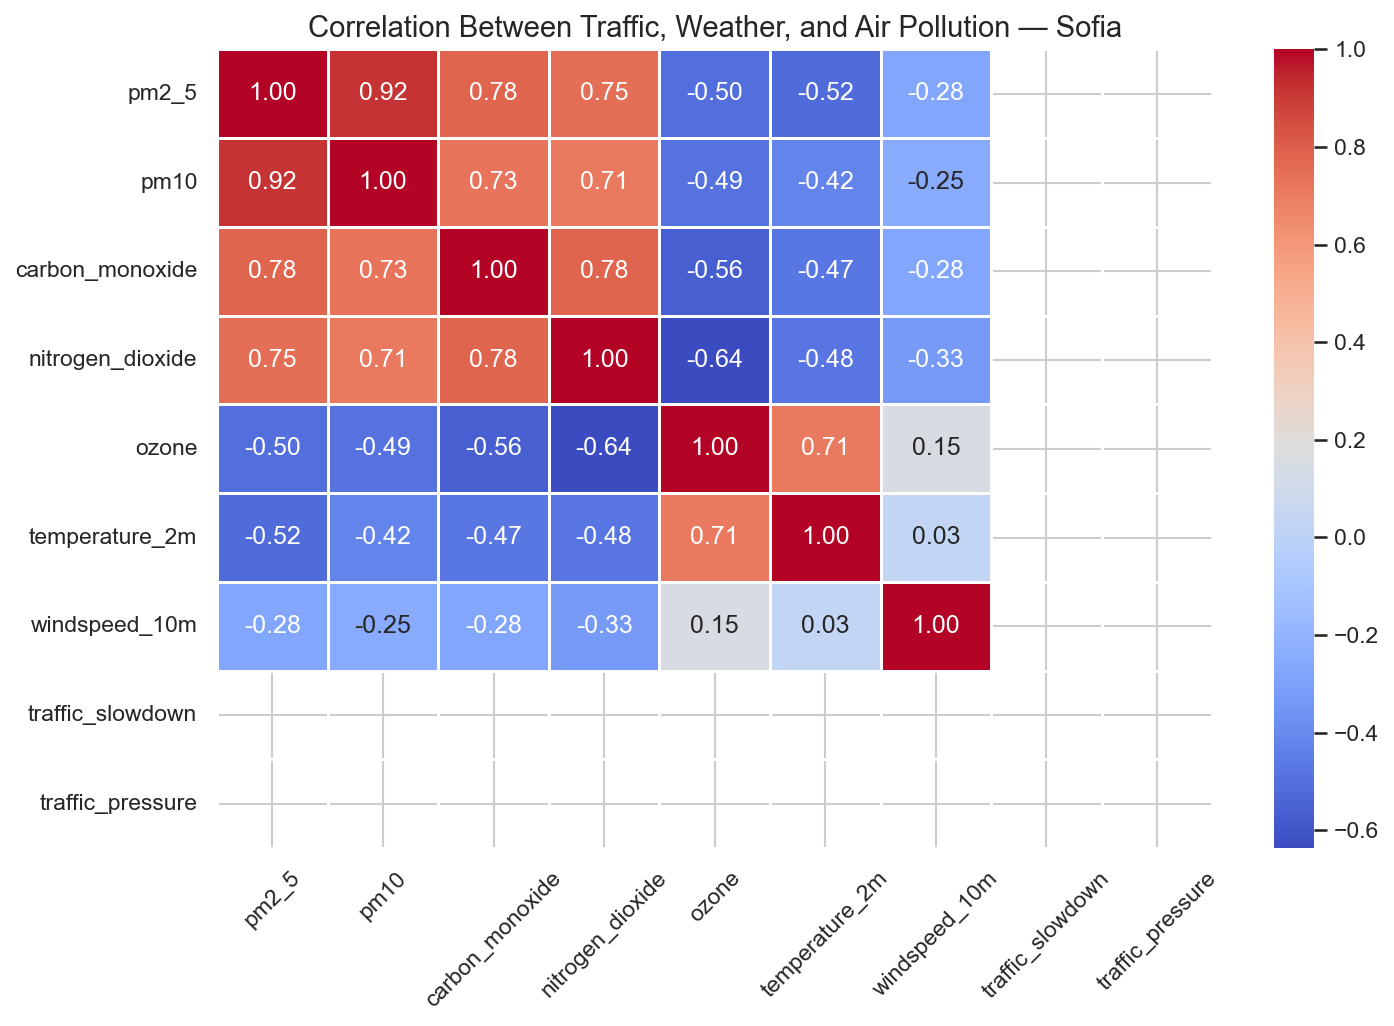

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_features = [
    "pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide", "ozone",
    "temperature_2m", "windspeed_10m", "traffic_slowdown", "traffic_pressure"
]


corr_matrix = df_final[corr_features].corr()


plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Traffic, Weather, and Air Pollution — Sofia", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


##  Focused Analysis — Traffic’s Impact on PM2.5
Now that traffic, weather, and air pollution data are merged, 
let’s isolate and analyze how traffic congestion (slowdown and pressure)
affects fine particulate pollution (PM2.5) in Sofia.


In [65]:

traffic_focus = df_final[[
    "time", "pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide",
    "traffic_slowdown", "traffic_pressure", "current_speed", "free_flow_speed"
]].dropna()

traffic_focus.head()


,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,traffic_slowdown,traffic_pressure,current_speed,free_flow_speed
0,2023-09-22 00:00:00,12.8,26.4,227.0,11.1,0.0,0.0,26.500000,41.025
1,2023-09-22 01:00:00,12.4,25.6,221.0,9.4,0.0,0.0,0.997266,78.000
2,2023-09-22 02:00:00,11.3,27.8,233.0,7.6,0.0,0.0,1.000000,78.000
3,2023-09-22 03:00:00,13.2,26.6,224.0,7.1,0.0,0.0,0.996354,78.000
4,2023-09-22 04:00:00,13.2,26.4,249.0,6.7,0.0,0.0,0.996354,78.000


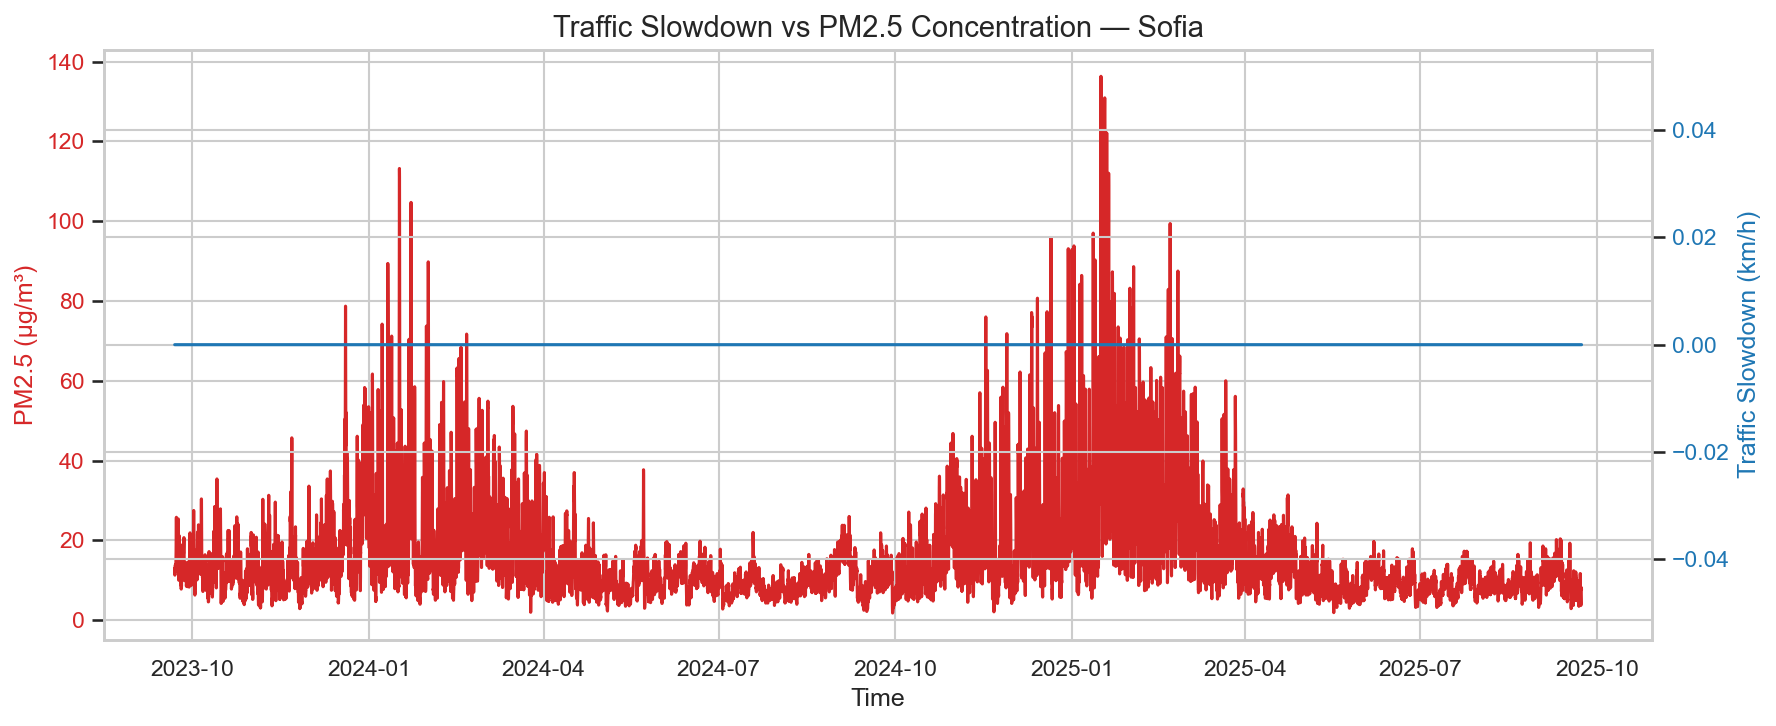

In [66]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.set_xlabel("Time")
ax1.set_ylabel("PM2.5 (µg/m³)", color="tab:red")
ax1.plot(traffic_focus["time"], traffic_focus["pm2_5"], color="tab:red", label="PM2.5")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.set_ylabel("Traffic Slowdown (km/h)", color="tab:blue")
ax2.plot(traffic_focus["time"], traffic_focus["traffic_slowdown"], color="tab:blue", label="Traffic Slowdown")
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.title("Traffic Slowdown vs PM2.5 Concentration — Sofia")
fig.tight_layout()
plt.show()



#  Reflection on Traffic Data 

After exploring traffic data availability for Sofia, I found that the dataset contained
too few records and lacked meaningful variation. Because of this limitation, I chose
not to include traffic analysis in the final version. 

Instead, I decided to focus on enhancing the web application — ensuring that it remains
functional, scalable, and ready for future integration when reliable traffic data
becomes available.
